# Homework 04: Building CNNs for Image Classification

### Due: September 27th at 11:59pm (with 2-hour + 1 minute grace period) and worth 85 points

In this assignment, you will take your first steps into designing and training convolutional neural networks (CNNs) for image classification. Starting from a simple baseline, you will experiment with modifications that reflect the kinds of design choices practitioners face every day. Along the way, you’ll see how architecture, hyperparameters, normalization, pooling strategies, and learning rate schedules can each shape a model’s performance.

The problems are organized to build on each other:

1. **Hyperparameters:** Begin with a baseline CNN and try variations in learning rate, layer width, depth, and dropout.
2. **Batch Normalization:** Add normalization after convolutional layers to stabilize training and speed convergence.
3. **Global Average Pooling:** Replace the flatten-and-dense head with a modern pooling layer, reducing parameters and improving generalization.
4. **ReduceLROnPlateau:** Explore a widely used learning rate scheduler that adapts when validation progress slows.
5. **Very Deep CNN:** Finally, run a VGG-16–style model to observe how deeper networks behave compared to smaller ones.

By the end of this homework, you will have hands-on experience with both classical and modern CNN design strategies, a sense of how different components affect learning, and a toolkit of techniques that will serve you in future image processing projects.

There are 10 graded questions, worth 8 points each, with 5 points free if you complete all of the graded questions in the homework.


## 1. Setup and Data Loading


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os,time,random,kagglehub

import tensorflow as tf
from tensorflow.keras import layers, Input, models, callbacks, regularizers,initializers
from tensorflow.keras.callbacks import Callback,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical, load_img, img_to_array
from tensorflow.keras.optimizers import Adam,AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img, img_to_array
from tensorflow.keras.layers import Dense,Input,Dropout,Flatten,MaxPooling2D,Conv2D,SeparableConv2D,GlobalAveragePooling2D,GlobalMaxPooling2D,BatchNormalization

from sklearn.model_selection import train_test_split

# utility code

# -------------------------
# Reproducibility settings
# -------------------------

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far

In [2]:

def plot_learning_curves(hist, title, verbose=True):

    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(),
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Testing and training sets already defined, accessed here as global variables

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Training and testing sets already defined, accessed here as global variables

In [3]:
# Uses globals: train_ds, val_ds, test_ds

def train_and_test(model,
                   epochs        = 500,
                   lr_schedule   = 1e-3,
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   use_early_stopping = True,
                   patience      = 10,
                   min_delta     = 0.001,
                   callbacks     = [],
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")

    # Choose optimizer
    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule)
    else:
        opt = optimizer

    # Compile
    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,
        verbose=verbose
    )

    cbs = ([early_stop] if use_early_stopping else []) + callbacks

    start = time.time()

    # Fit on tf.data datasets (already batched)
    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=cbs,
        verbose=verbose
    )

    # Determine best validation accuracy
    if use_early_stopping and hasattr(early_stop, "best_epoch") and early_stop.best_epoch is not None:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = int(np.argmax(history.history['val_accuracy']))
        best_acc   = history.history['val_accuracy'][best_epoch]

    plot_learning_curves(history, title=title)

    # Evaluate on tf.data test set
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")

    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history


### Load the Intel Image Classification Dataset  



In [4]:
path      = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test")

In [5]:
# --------------------------------------------------
# DATASET SIZE
#
# For faster experimentation on a slower computer,
# you may reduce DATA_FRACTION (for example, to 0.25).
#
# IMPORTANT: Set DATA_FRACTION = 1.0 and rerun the
# complete notebook before recording your final results.
# --------------------------------------------------

DATA_FRACTION = 1.0

AUTOTUNE = tf.data.AUTOTUNE

def stratified_subsample(filepaths, labels, fraction=1.0, seed=42):
    """
    Keep the same fraction of examples from each class.
    fraction=1.0 uses the complete dataset.
    """
    if fraction >= 1.0:
        return filepaths, labels

    rng = np.random.default_rng(seed)

    keep_idx = []

    for c in np.unique(labels):
        idx = np.flatnonzero(labels == c)
        rng.shuffle(idx)

        n_keep = max(1, int(len(idx) * fraction))
        keep_idx.extend(idx[:n_keep])

    keep_idx = np.array(keep_idx)
    rng.shuffle(keep_idx)

    return filepaths[keep_idx], labels[keep_idx]

def list_files_and_labels(directory, class_names=None, exts=(".jpg", ".jpeg", ".png")):
    """
    Returns:
      filepaths: np.array[str]
      labels:    np.array[int32]
      class_names_used: list[str] in deterministic order
    """
    if class_names is None:
        class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
    else:
        # keep only classes that exist in this directory, preserve given order
        class_names = [c for c in class_names if os.path.isdir(os.path.join(directory, c))]

    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    filepaths = []
    labels = []

    for cname in class_names:
        folder = os.path.join(directory, cname)
        for fname in sorted(os.listdir(folder)):  # deterministic within class
            if fname.lower().endswith(exts):
                filepaths.append(os.path.join(folder, fname))
                labels.append(class_to_idx[cname])

    return np.array(filepaths), np.array(labels, dtype=np.int32), class_names


def stratified_split_indices(y, val_frac=0.2, seed=42):
    """
    Deterministic stratified split over indices.
    Returns: train_idx, val_idx (np arrays)
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    n = len(y)

    train_idx_list = []
    val_idx_list = []

    classes = np.unique(y)
    for c in classes:
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        n_val = int(np.floor(len(idx) * val_frac))
        val_idx_list.append(idx[:n_val])
        train_idx_list.append(idx[n_val:])

    train_idx = np.concatenate(train_idx_list)
    val_idx = np.concatenate(val_idx_list)

    # Optional: shuffle each split deterministically so batches mix classes
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx


def make_image_dataset(filepaths, labels, img_size=(150, 150), batch_size=32,
                       shuffle=False, seed=42, cache_to_disk=None):
    """
    Builds a tf.data.Dataset that loads images lazily from disk.
    - filepaths: np array of strings
    - labels:    np array of int32
    """
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        # shuffle file *references* (cheap), not image tensors
        ds = ds.shuffle(buffer_size=len(filepaths), seed=seed, reshuffle_each_iteration=True)

    def _load_and_preprocess(path, label):
        # read bytes -> decode -> resize -> float32 in [0,1]
        img_bytes = tf.io.read_file(path)
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.image.resize(img, img_size, method="bilinear")
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = ds.map(_load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if cache_to_disk is not None:
        # Disk caching avoids RAM blowups; /tmp is fine in Colab
        ds = ds.cache(cache_to_disk)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# -------------------------
# Example usage for Intel dataset
# -------------------------

IMG_SIZE      = (150, 150)
INPUT_SHAPE   = IMG_SIZE + (3,)
BATCH_SIZE    = 32
VAL_FRAC      = 0.2
SEED          = random_seed  # use your existing seed


# 1) List train files/labels deterministically
train_files, train_labels, class_names = list_files_and_labels(train_dir)

num_classes = len(class_names)

# Optional: use a smaller stratified subset while developing/debugging
train_files, train_labels = stratified_subsample(
    train_files,
    train_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

# 2) Stratified deterministic train/validation split
train_idx, val_idx = stratified_split_indices(
    train_labels,
    val_frac=VAL_FRAC,
    seed=SEED,
)

# 3) Slice file lists
files_train = train_files[train_idx]
y_train     = train_labels[train_idx]

files_val   = train_files[val_idx]
y_val       = train_labels[val_idx]

# 4) Build datasets
train_ds = make_image_dataset(
    files_train,
    y_train,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    cache_to_disk=None,
)

val_ds = make_image_dataset(
    files_val,
    y_val,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)

# 5) Test set
test_files, test_labels, _ = list_files_and_labels(
    test_dir,
    class_names=class_names,
)

# Use the same fraction for quick development runs
test_files, test_labels = stratified_subsample(
    test_files,
    test_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

test_ds = make_image_dataset(
    test_files,
    test_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)



### Examine The Dataset

In [9]:

def show_counts_from_labels(name, labels, class_names):
    c = Counter(labels.tolist())
    counts = {class_names[k]: c.get(k, 0) for k in range(len(class_names))}
    print(f"{name} per-class counts:", counts)

print("class_names:", class_names)
print("train examples:", len(files_train), "val examples:", len(files_val), "test examples:", len(test_files))

show_counts_from_labels("train", y_train, class_names)
show_counts_from_labels("val",   y_val,   class_names)
show_counts_from_labels("test",  test_labels, class_names)


class_names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
train examples: 11230 val examples: 2804 test examples: 3000
train per-class counts: {'buildings': 1753, 'forest': 1817, 'glacier': 1924, 'mountain': 2010, 'sea': 1820, 'street': 1906}
val per-class counts: {'buildings': 438, 'forest': 454, 'glacier': 480, 'mountain': 502, 'sea': 454, 'street': 476}
test per-class counts: {'buildings': 437, 'forest': 474, 'glacier': 553, 'mountain': 525, 'sea': 510, 'street': 501}


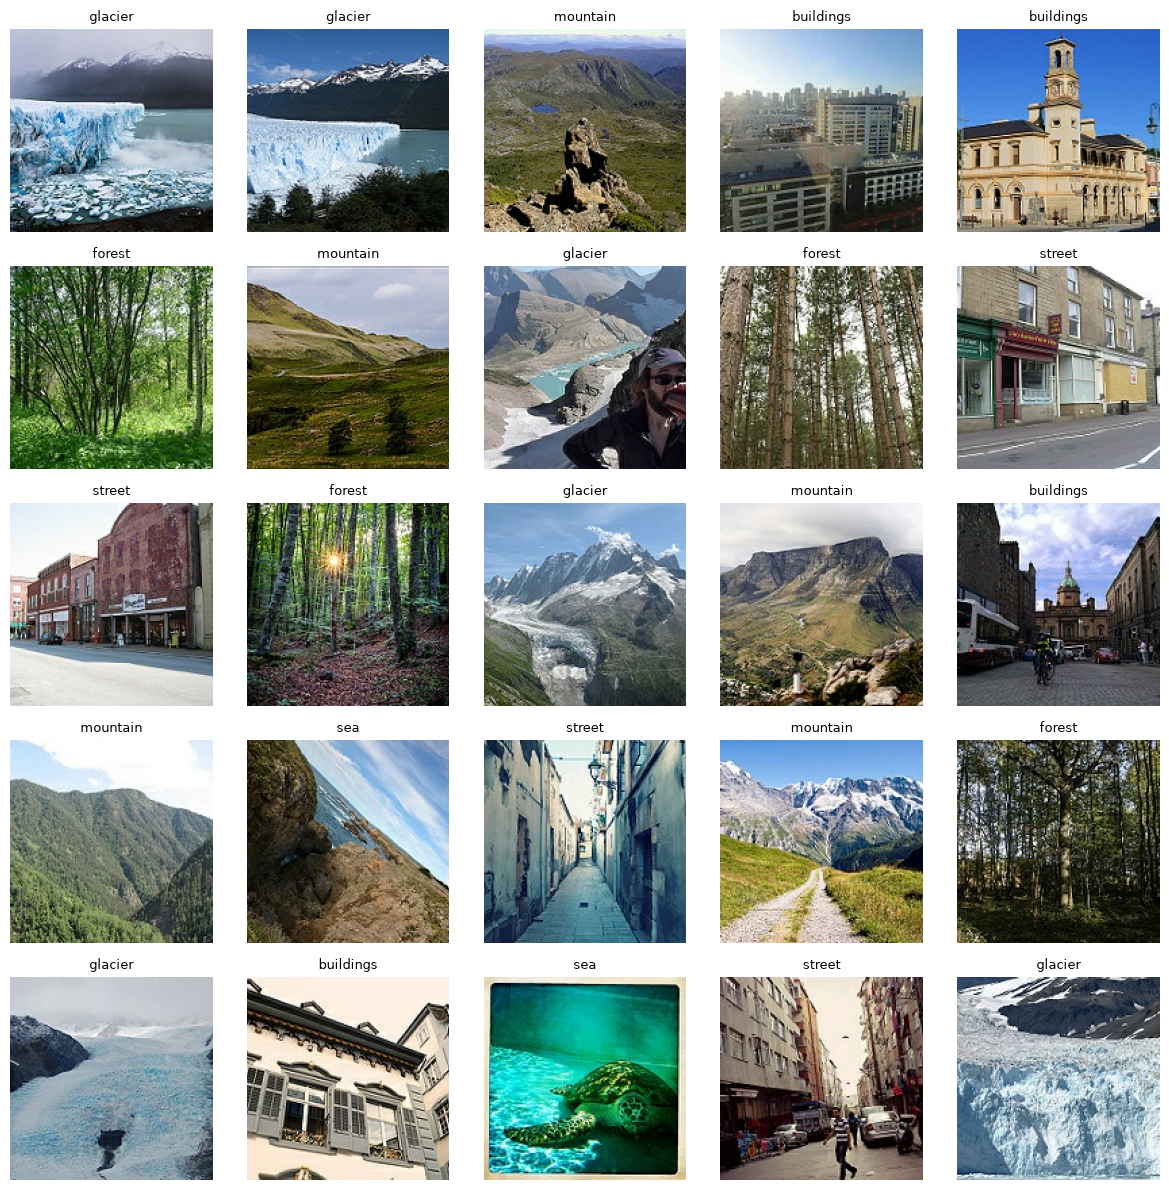

In [10]:
# Show 25 sample images

plt.figure(figsize=(12, 12))

# Take one batch from the dataset
images, labels = next(iter(train_ds))

for i in range(25):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(class_names[int(labels[i])], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Prelude: Baseline CNN (reference model)

This is our **reference** network: two Conv→Pool blocks with channels **32 → 64**, followed by a **single hidden head** `Dense(64)`. We use **He** initialization for ReLU activations and include an **optional `Dropout(0.5)`** to illustrate regularization—comment it out to gauge its impact (ha, not really optional!).

Use this model as a stable yardstick while you run **ablations**: change **one knob at a time** (e.g., widen/deepen the conv blocks, adjust dropout rate, add batch norm, tweak the LR schedule) and compare results back to this baseline. Focus on **training vs. validation curves**, the **generalization gap**, and how dropout affects **val loss/accuracy** and how long it takes for Early Stopping to kick in.


> **Note:** On rare runs, training may become numerically unstable and produce `NaN` loss values. If this occurs, rerun the model. If the problem persists, restart the runtime and run the notebook again from the beginning.

In [6]:
# enabling GPU
os.environ["KERAS_BACKEND"] = "torch"


Baseline Model



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


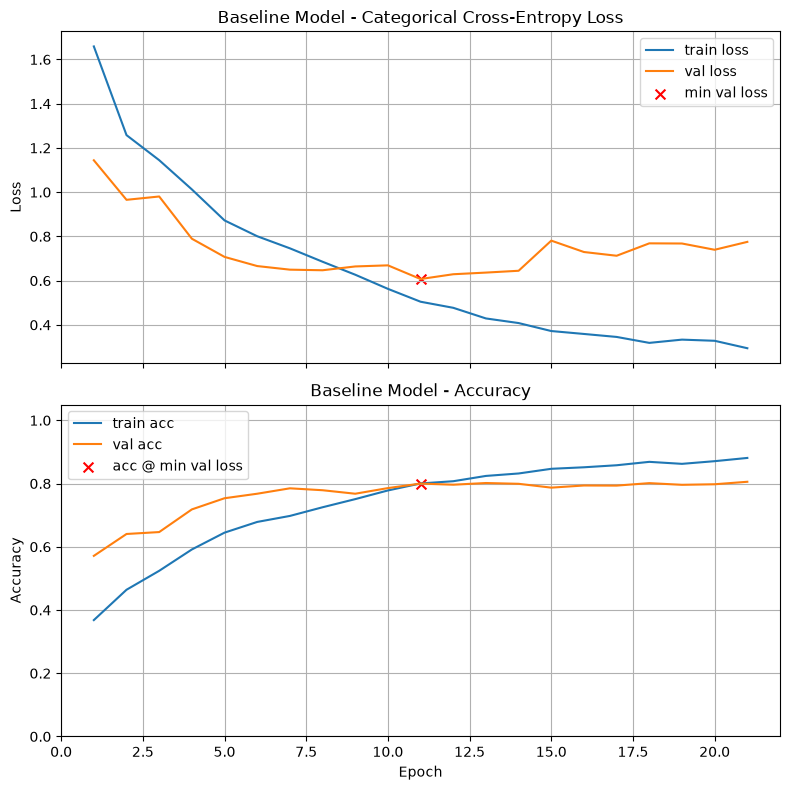

Final Training Loss:            0.2945
Final Training Accuracy:        0.8810
Final Validation Loss:          0.7753
Final Validation Accuracy:      0.8056
Minimum Validation Loss:        0.6073 (Epoch 11)
Validation Accuracy @ Min Loss: 0.7999

Test Loss: 0.6441
Test Accuracy: 0.7900

Validation-Test Gap (accuracy): 0.009929

Execution Time: 00:06:22


In [11]:
he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"Baseline Model")


## Problem One: Exploring Basic Hyperparameters

**Task:**
Copy the baseline CNN model into the next cell and experiment with basic hyperparameter changes. Your goal is to see whether small tweaks can improve validation accuracy (and hopefully speed up convergence or produce smoother training curves). You must **pick 3 of the following tweaks** and investigate their effect:

**Tweaks to Try:**

1. Adjust the learning rate (default for Adam is `1e-3`).
2. Change the width of the `Conv2D` layers (e.g., 64 → 128).
3. Add an extra `Conv2D` layer (e.g., stack 32 → 64 → 128).
4. Change the width of the `Dense(64 ...)` layer.
5. Add L2 regularization to the `Dense(64 ...)` layer (see the head of the network in Problem 5 for inspiration).  
6. Modify the dropout rate.
   
Observe the effect of each of your 3 choices in isolation and answer the graded questions.

**Optional:**
Combine two or more changes to see if they work together to improve results (example: try L2 regularization and reduced dropout in the head, as in Problem 5).


**Pro Tip:** Give each experiment a descriptive title, such as "Problem 1 -- Tweak 1 -- lr: 0.0005" to keep track of your experiments (see last cell in the notebook).


P1: Baseline Model with LR = 0.0005



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


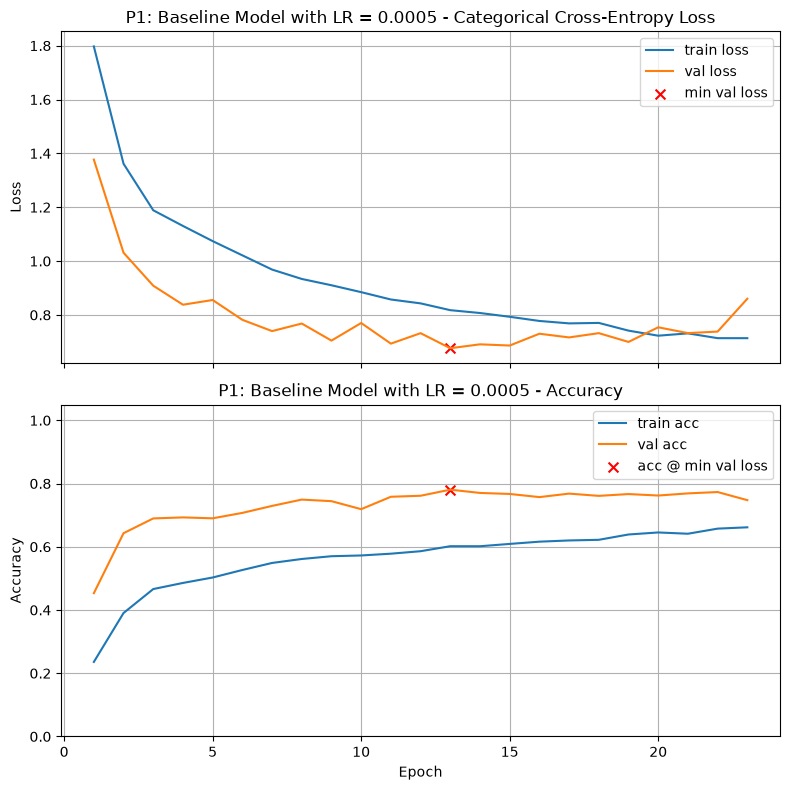

Final Training Loss:            0.7138
Final Training Accuracy:        0.6616
Final Validation Loss:          0.8602
Final Validation Accuracy:      0.7475
Minimum Validation Loss:        0.6765 (Epoch 13)
Validation Accuracy @ Min Loss: 0.7807

Test Loss: 0.7039
Test Accuracy: 0.7723

Validation-Test Gap (accuracy): 0.008337

Execution Time: 00:07:12


In [13]:
he = initializers.HeNormal()                                # best initializer for relu
lr = 5e-4

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, lr_schedule=lr, title=f"P1: Baseline Model with LR = {lr}")



P1: Baseline Model with 3rd Conv2D (128)



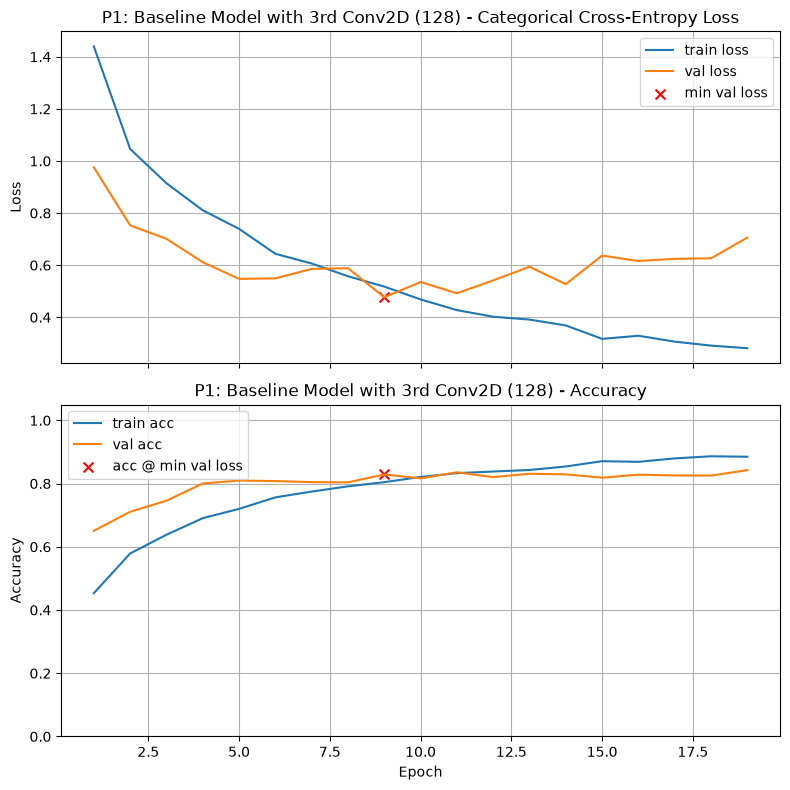

Final Training Loss:            0.2813
Final Training Accuracy:        0.8848
Final Validation Loss:          0.7059
Final Validation Accuracy:      0.8424
Minimum Validation Loss:        0.4769 (Epoch 9)
Validation Accuracy @ Min Loss: 0.8288

Test Loss: 0.5340
Test Accuracy: 0.8290

Validation-Test Gap (accuracy): 0.000184

Execution Time: 00:07:48


In [14]:
he = initializers.HeNormal()                                # best initializer for relu

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, title=f"P1: Baseline Model with 3rd Conv2D (128)")



P1: Baseline Model with 2nd Conv2D = 128



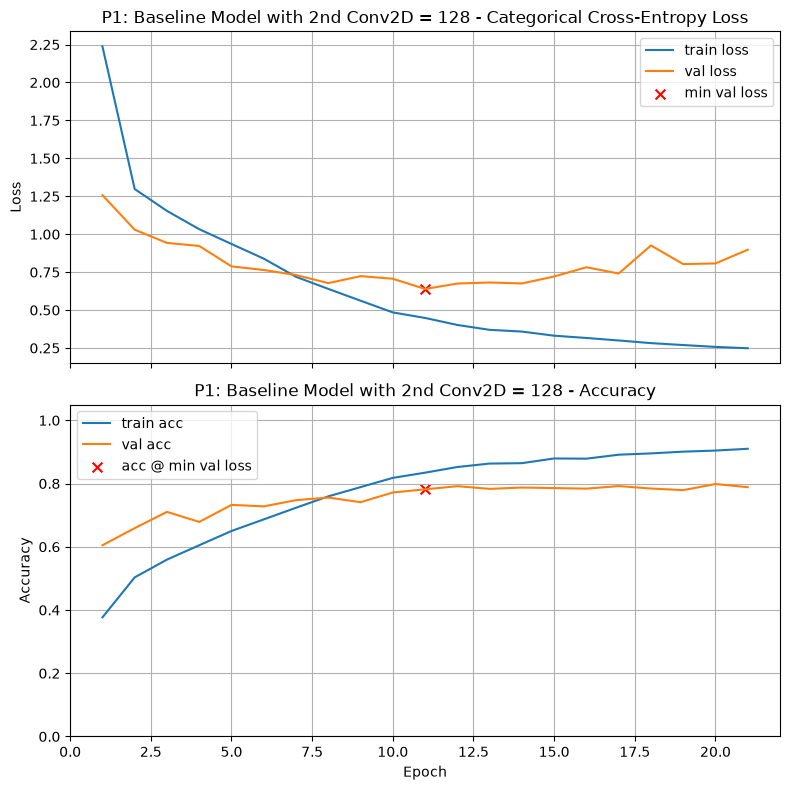

Final Training Loss:            0.2487
Final Training Accuracy:        0.9100
Final Validation Loss:          0.8979
Final Validation Accuracy:      0.7885
Minimum Validation Loss:        0.6391 (Epoch 11)
Validation Accuracy @ Min Loss: 0.7817

Test Loss: 0.7110
Test Accuracy: 0.7797

Validation-Test Gap (accuracy): 0.002074

Execution Time: 00:10:28


In [15]:
he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"P1: Baseline Model with 2nd Conv2D = 128")


In [16]:
print_results()

P1: Baseline Model with 3rd Conv2D (128)	0.8288	9
Baseline Model                          	0.7999	11
P1: Baseline Model with 2nd Conv2D = 128	0.7817	11
P1: Baseline Model with LR = 0.0005     	0.7807	13


### Graded Questions

In [17]:
# Set a1a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

a1a = 3             # Replace with integer 1 - 6; replace with -1 if you found no tweak which improved the results

In [18]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a1a = {a1a}')


a1a = 3


In [19]:
# Set a1b to the validation accuracy found by the choice specified in Question a1a.

a1b = results['P1: Baseline Model with 3rd Conv2D (128)'][0]             # Replace 0.0 with your answer

In [20]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a1b = {a1b:.4f}')

a1b = 0.8288


## Problem Two: Adding Batch Normalization

**Task:**
Take your best model from Problem One and add a `BatchNormalization()` layer immediately after each `Conv2D` layer. Batch normalization helps stabilize training and can improve convergence.

**Next Steps:**

* Train the model with batch normalization included after each `Conv2D` layer.
* Try at least one of tweaks from Problem 1 to see if you can improve your results in this new design.
* Compare the results to your earlier experiments and answer the graded questions.

**Optional:**
Try more than one hyperparameter change alongside batch normalization and see how they interact.




P2: Baseline with 3rd Conv2D (128) and Batch Normalization



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


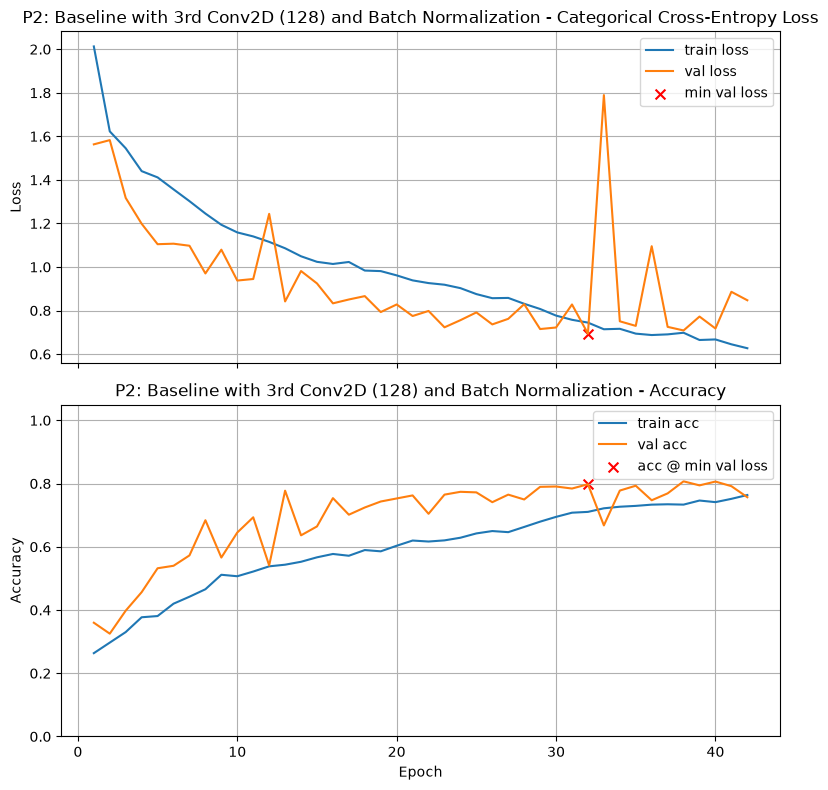

Final Training Loss:            0.6269
Final Training Accuracy:        0.7638
Final Validation Loss:          0.8472
Final Validation Accuracy:      0.7568
Minimum Validation Loss:        0.6939 (Epoch 32)
Validation Accuracy @ Min Loss: 0.7978

Test Loss: 0.6978
Test Accuracy: 0.8057

Validation-Test Gap (accuracy): 0.007878

Execution Time: 00:25:55


In [21]:
he = initializers.HeNormal()                                # best initializer for relu

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, title=f"P2: Baseline with 3rd Conv2D (128) and Batch Normalization")



P2: Baseline with 3rd Conv2D (128), Batch Normalization, 0.3 DO



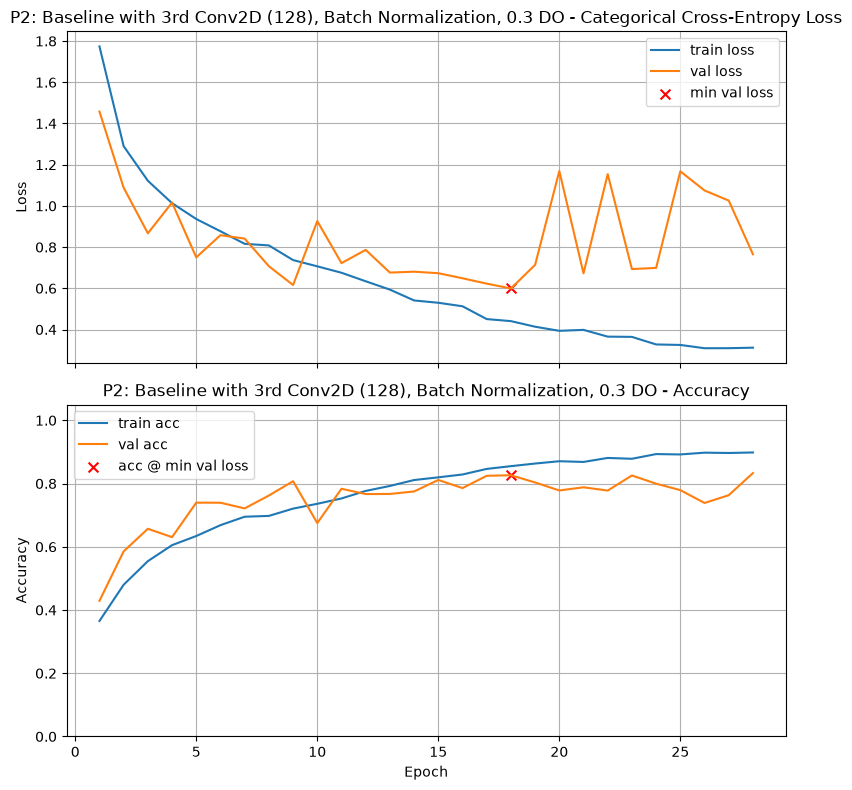

Final Training Loss:            0.3120
Final Training Accuracy:        0.8983
Final Validation Loss:          0.7653
Final Validation Accuracy:      0.8331
Minimum Validation Loss:        0.5992 (Epoch 18)
Validation Accuracy @ Min Loss: 0.8263

Test Loss: 0.6225
Test Accuracy: 0.8257

Validation-Test Gap (accuracy): 0.000653

Execution Time: 00:16:28


In [22]:
he = initializers.HeNormal()                                # best initializer for relu

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, title=f"P2: Baseline with 3rd Conv2D (128), Batch Normalization, 0.3 DO")



P2: Baseline with 3rd Conv2D (128), Batch Normalization, 0.4 DO



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


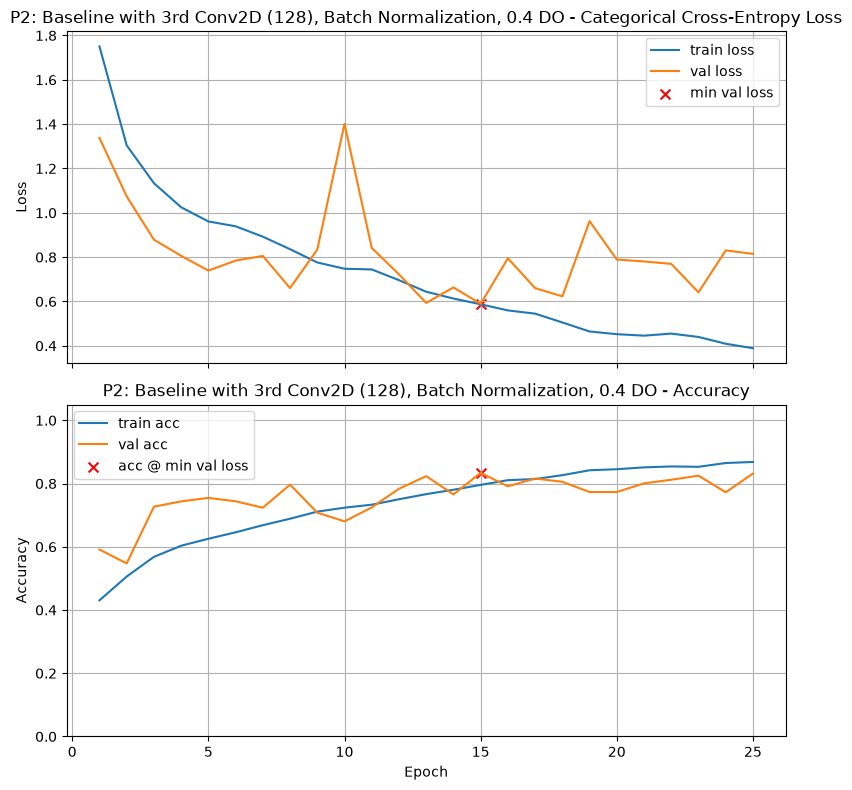

Final Training Loss:            0.3890
Final Training Accuracy:        0.8683
Final Validation Loss:          0.8148
Final Validation Accuracy:      0.8317
Minimum Validation Loss:        0.5892 (Epoch 15)
Validation Accuracy @ Min Loss: 0.8338

Test Loss: 0.5823
Test Accuracy: 0.8373

Validation-Test Gap (accuracy): 0.003524

Execution Time: 00:14:42


In [23]:
he = initializers.HeNormal()                                # best initializer for relu

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, title=f"P2: Baseline with 3rd Conv2D (128), Batch Normalization, 0.4 DO")



P2: Baseline with 3rd Conv2D (128), Batch Normalization, Dense (128)



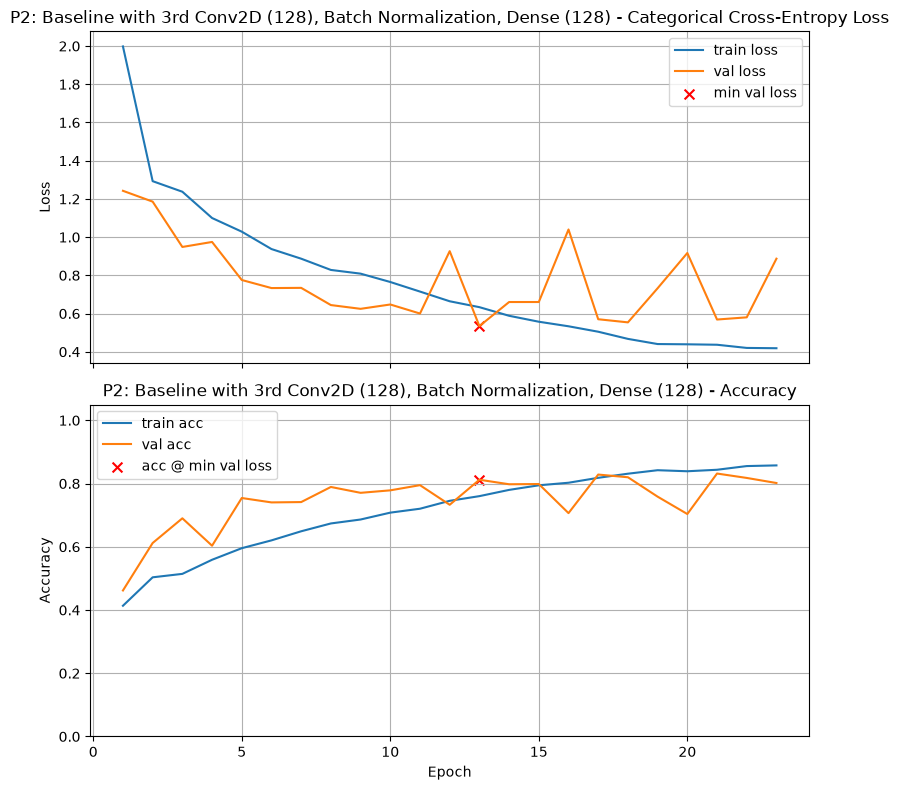

Final Training Loss:            0.4186
Final Training Accuracy:        0.8574
Final Validation Loss:          0.8872
Final Validation Accuracy:      0.8017
Minimum Validation Loss:        0.5344 (Epoch 13)
Validation Accuracy @ Min Loss: 0.8121

Test Loss: 0.5323
Test Accuracy: 0.8240

Validation-Test Gap (accuracy): 0.011946

Execution Time: 00:13:45


In [24]:
he = initializers.HeNormal()                                # best initializer for relu

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Flatten(),
    Dense(128, activation="relu",kernel_initializer=he),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, title=f"P2: Baseline with 3rd Conv2D (128), Batch Normalization, Dense (128)")


In [25]:
print_results()

P2: Baseline with 3rd Conv2D (128), Batch Normalization, 0.4 DO	0.8338	15
P1: Baseline Model with 3rd Conv2D (128)	0.8288	9
P2: Baseline with 3rd Conv2D (128), Batch Normalization, 0.3 DO	0.8263	18
P2: Baseline with 3rd Conv2D (128), Batch Normalization, Dense (128)	0.8121	13
Baseline Model                          	0.7999	11
P2: Baseline with 3rd Conv2D (128) and Batch Normalization	0.7978	32
P1: Baseline Model with 2nd Conv2D = 128	0.7817	11
P1: Baseline Model with LR = 0.0005     	0.7807	13


### Graded Questions

In [30]:
# Set a2a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

a2a = 6             # Replace with integer 1 - 6; replace with -1 if you found no tweak which improved the results

In [31]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a2a = {a2a}')


a2a = 6


In [32]:
# Set a2b to the validation accuracy found by the choice specified in Question a2a (your best model for this problem)

a2b = results['P2: Baseline with 3rd Conv2D (128), Batch Normalization, 0.4 DO'][0]             # Replace 0.0 with your answer

In [33]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a2b = {a2b:.4f}')

a2b = 0.8338


## Problem Three: Global Average Pooling

As we saw in this week's Coding Video,
**Global Average Pooling** is a simple layer that replaces the `Flatten → Dense` part of a CNN (please review that part of the Coding Notebook, which contains a description of this important technique).

In practice, swapping `Flatten` for `GlobalAveragePooling2D` often improves stability and validation performance — definitely worth considering!


**Task:**
Modify your best model from Problems 1 & 2 to use a `GlobalAveragePooling2D()` layer instead of a flatten-and-dense block.

**Next Steps:**

* Replace the sequence between the last `Conv2D` and output layers, for example:

     
          MaxPooling2D((2, 2)),
          Flatten(),
          Dense(64, activation='relu', kernel_initializer=initializers.HeNormal()),
          Dropout(0.5),   

  with a single `GlobalAveragePooling2D()` layer.
* Train the model and observe how performance and training curves change.
* Try at least one of tweaks from Problem 1 to see if you can improve your results in this new design.
* Compare results and answer the graded questions.

**Optional:**
Experiment with `GlobalMaxPooling2D()` as an alternative and compare its behavior to `GlobalAveragePooling2D()`.




P3: Baseline with 3rd Conv2D (128), Batch Normalization, Global Avg Pool



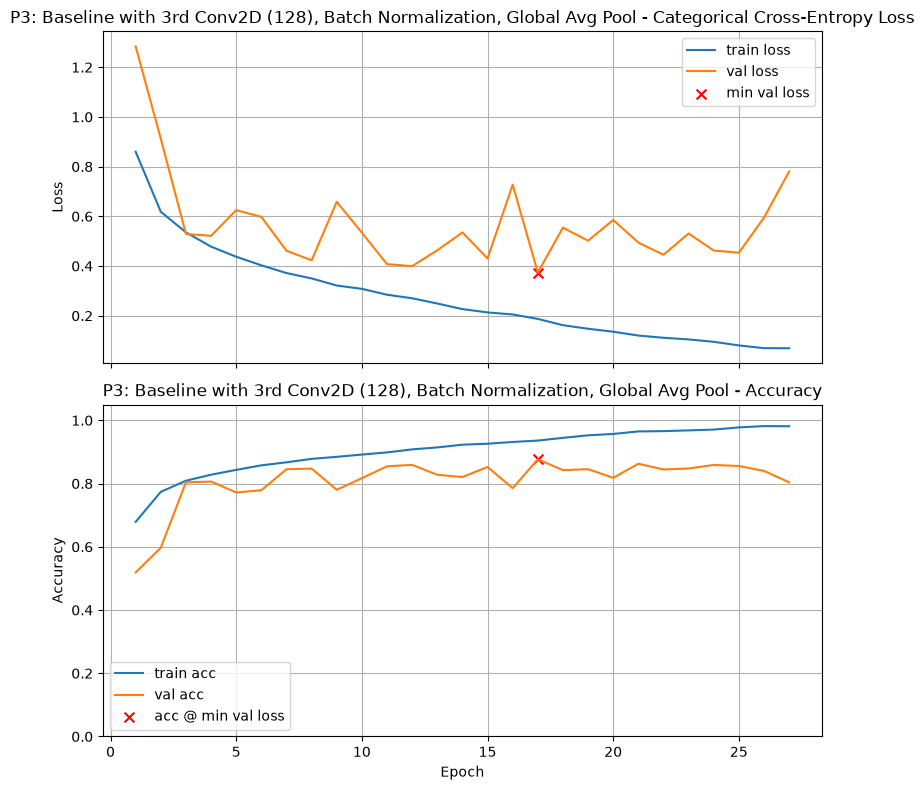

Final Training Loss:            0.0691
Final Training Accuracy:        0.9813
Final Validation Loss:          0.7806
Final Validation Accuracy:      0.8039
Minimum Validation Loss:        0.3736 (Epoch 17)
Validation Accuracy @ Min Loss: 0.8766

Test Loss: 0.3696
Test Accuracy: 0.8757

Validation-Test Gap (accuracy): 0.000938

Execution Time: 00:15:48


In [35]:
he = initializers.HeNormal()                                # best initializer for relu

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, title=f"P3: Baseline with 3rd Conv2D (128), Batch Normalization, Global Avg Pool")



P3: Baseline with LR (0.005), 3rd Conv2D (128), Batch Normalization, Global Avg Pool



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


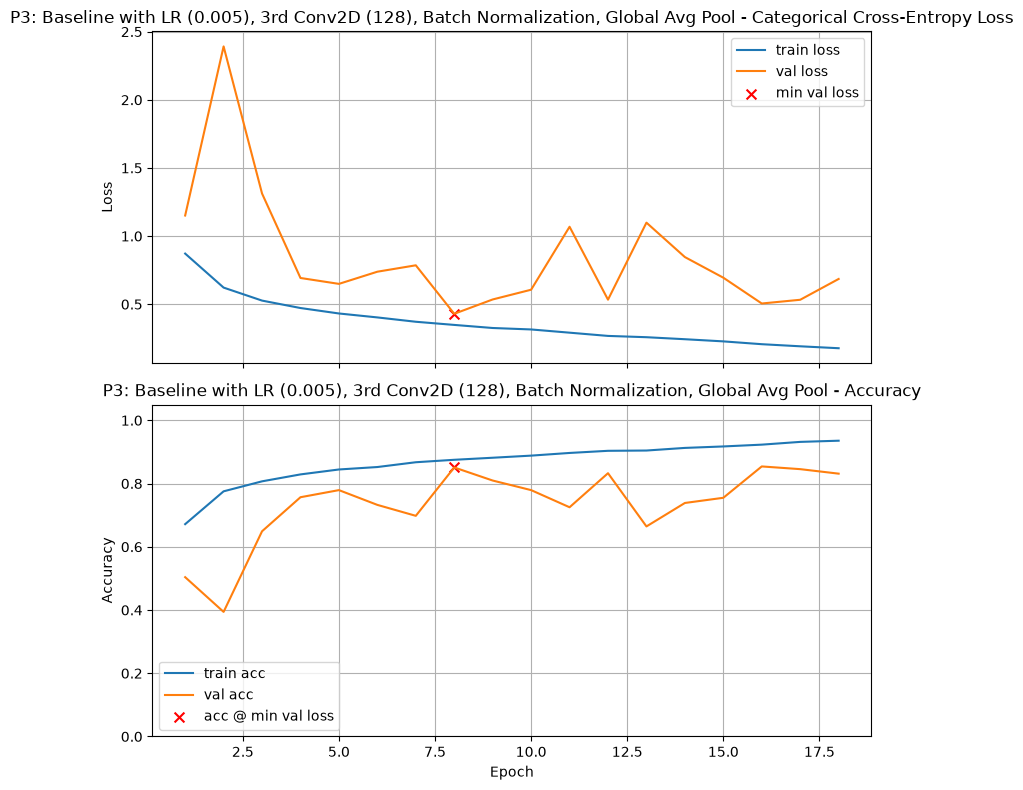

Final Training Loss:            0.1772
Final Training Accuracy:        0.9355
Final Validation Loss:          0.6855
Final Validation Accuracy:      0.8313
Minimum Validation Loss:        0.4300 (Epoch 8)
Validation Accuracy @ Min Loss: 0.8509

Test Loss: 0.4278
Test Accuracy: 0.8463

Validation-Test Gap (accuracy): 0.004594

Execution Time: 00:10:37


In [36]:
he = initializers.HeNormal()                                # best initializer for relu

lr = 5e-3

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, lr_schedule=lr, title=f"P3: Baseline with LR ({lr}), 3rd Conv2D (128), Batch Normalization, Global Avg Pool")



P3: Baseline with LR (0.0001), 3rd Conv2D (128), Batch Normalization, Global Avg Pool



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


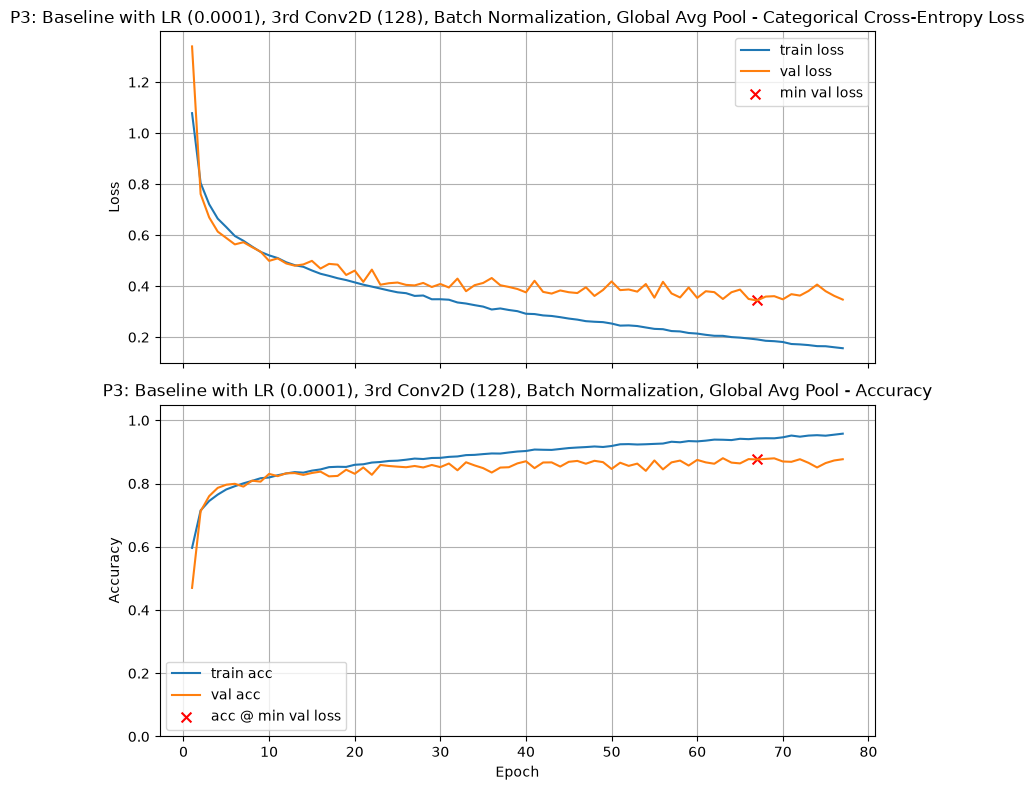

Final Training Loss:            0.1566
Final Training Accuracy:        0.9578
Final Validation Loss:          0.3473
Final Validation Accuracy:      0.8770
Minimum Validation Loss:        0.3438 (Epoch 67)
Validation Accuracy @ Min Loss: 0.8762

Test Loss: 0.3513
Test Accuracy: 0.8783

Validation-Test Gap (accuracy): 0.002085

Execution Time: 00:46:18


In [37]:
he = initializers.HeNormal()                                # best initializer for relu

lr = 1e-4

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, lr_schedule=lr, title=f"P3: Baseline with LR ({lr}), 3rd Conv2D (128), Batch Normalization, Global Avg Pool")



P3: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normalization, Global Avg Pool



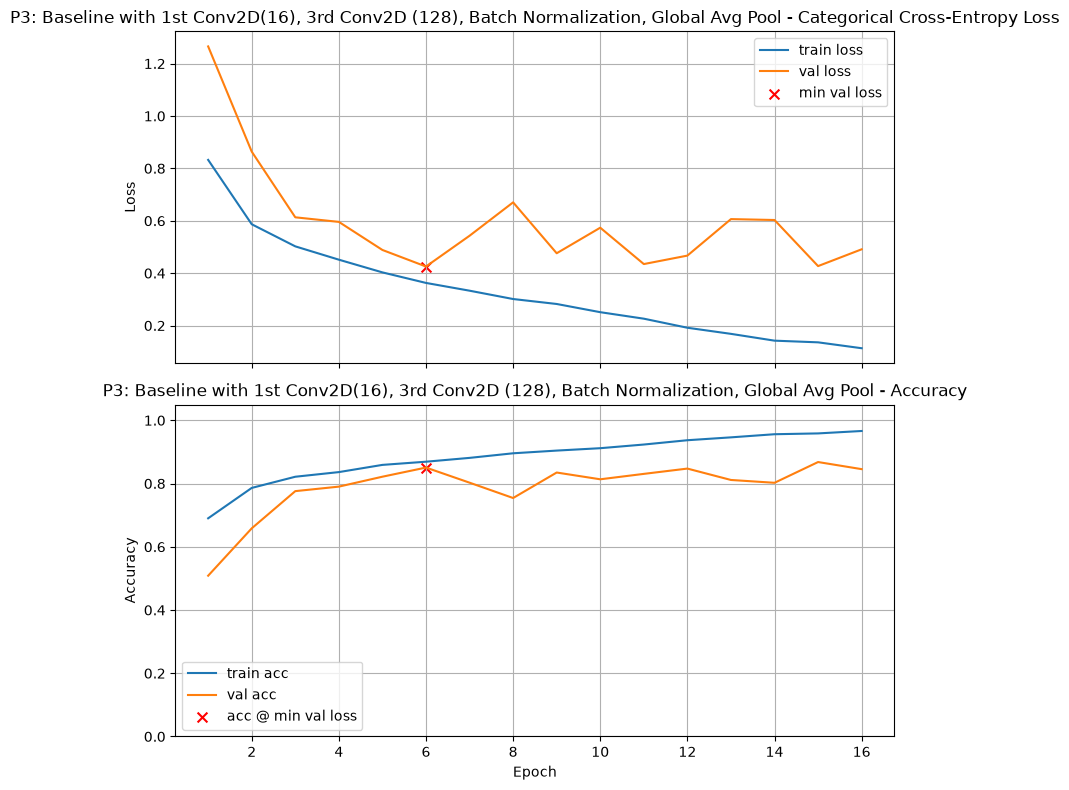

Final Training Loss:            0.1135
Final Training Accuracy:        0.9663
Final Validation Loss:          0.4911
Final Validation Accuracy:      0.8456
Minimum Validation Loss:        0.4254 (Epoch 6)
Validation Accuracy @ Min Loss: 0.8506

Test Loss: 0.4276
Test Accuracy: 0.8490

Validation-Test Gap (accuracy): 0.001571

Execution Time: 00:04:12


In [38]:
he = initializers.HeNormal()                                # best initializer for relu

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),  
    MaxPooling2D(2),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, title=f"P3: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normalization, Global Avg Pool")



P3: Baseline with 3rd Conv2D (128), Batch Normalization, Global Max Pool



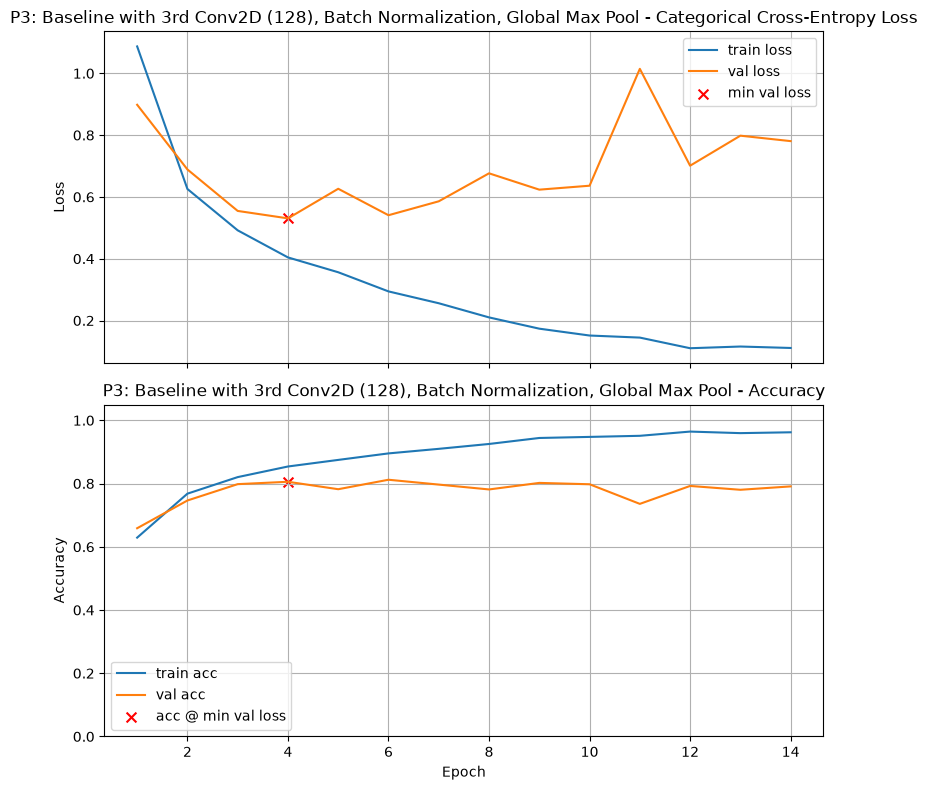

Final Training Loss:            0.1112
Final Training Accuracy:        0.9622
Final Validation Loss:          0.7806
Final Validation Accuracy:      0.7910
Minimum Validation Loss:        0.5306 (Epoch 4)
Validation Accuracy @ Min Loss: 0.8056

Test Loss: 0.5305
Test Accuracy: 0.8067

Validation-Test Gap (accuracy): 0.001032

Execution Time: 00:07:56


In [39]:
he = initializers.HeNormal()                                # best initializer for relu

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalMaxPooling2D(),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, title=f"P3: Baseline with 3rd Conv2D (128), Batch Normalization, Global Max Pool")


In [40]:
print_results()

P3: Baseline with 3rd Conv2D (128), Batch Normalization, Global Avg Pool	0.8766	17
P3: Baseline with LR (0.0001), 3rd Conv2D (128), Batch Normalization, Global Avg Pool	0.8762	67
P3: Baseline with LR (0.005), 3rd Conv2D (128), Batch Normalization, Global Avg Pool	0.8509	8
P3: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normalization, Global Avg Pool	0.8506	6
P2: Baseline with 3rd Conv2D (128), Batch Normalization, 0.4 DO	0.8338	15
P1: Baseline Model with 3rd Conv2D (128)	0.8288	9
P2: Baseline with 3rd Conv2D (128), Batch Normalization, 0.3 DO	0.8263	18
P2: Baseline with 3rd Conv2D (128), Batch Normalization, Dense (128)	0.8121	13
P3: Baseline with 3rd Conv2D (128), Batch Normalization, Global Max Pool	0.8056	4
Baseline Model                          	0.7999	11
P2: Baseline with 3rd Conv2D (128) and Batch Normalization	0.7978	32
P1: Baseline Model with 2nd Conv2D = 128	0.7817	11
P1: Baseline Model with LR = 0.0005     	0.7807	13


### Graded Questions

In [41]:
# Set a3a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

a3a = 3             # Replace with integer 1 - 6; replace with -1 if you found no tweak which improved the results

In [42]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a3a = {a3a}')


a3a = 3


In [43]:
# Set a3b to the validation accuracy found by the choice specified in Question a3a (your best model for this problem)

a3b = results['P3: Baseline with 3rd Conv2D (128), Batch Normalization, Global Avg Pool'][0]             # Replace 0.0 with your answer

In [44]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a3b = {a3b:.4f}')

a3b = 0.8766


## Problem Four: ReduceLROnPlateau

`ReduceLROnPlateau` is a widely used learning rate scheduling technique. It monitors a validation metric (usually `val_loss`) and reduces the learning rate when progress stalls, allowing the model to refine training at a smaller step size. This is one of the most useful scheduling tools (along with the essential Early Stopping) to have in your toolbox.

**Task:**
Augment your best model found so far in Problems 1 - 3 with the `ReduceLROnPlateau` callback during training.

**Next Steps:**

* Add the callback parameter to `train_and_test`:

  ```python
  callbacks=[reduce_lr]
  ```

* Start with **`factor=0.5`** (monitor `val_loss`, `patience=2–3`, `cooldown=1`, `min_lr=1e-5` for Adam).
* **Practical playbook:**

  * If plateau persists after one reduction → try **`factor=0.3`**, then **`0.2`**.
  * If a reduction hurts validation noticeably → try **`factor=0.7–0.8`** or increase **`patience`**.
  * Leave **`cooldown=1`** unless you see too-frequent drops.
* Experiment with **`patience` = 3, 5, 8** and **`min_delta` = `1e-4` vs `1e-3`** to gauge sensitivity.
* Choose the configuration with the best validation results—or note that ReduceLROnPlateau didn’t help (rare!).
* Answer the graded questions.




P3: Baseline with LR (0.0001), 3rd Conv2D (128), Batch Normalization, Global Avg Pool, ReduceLROnPlateau default



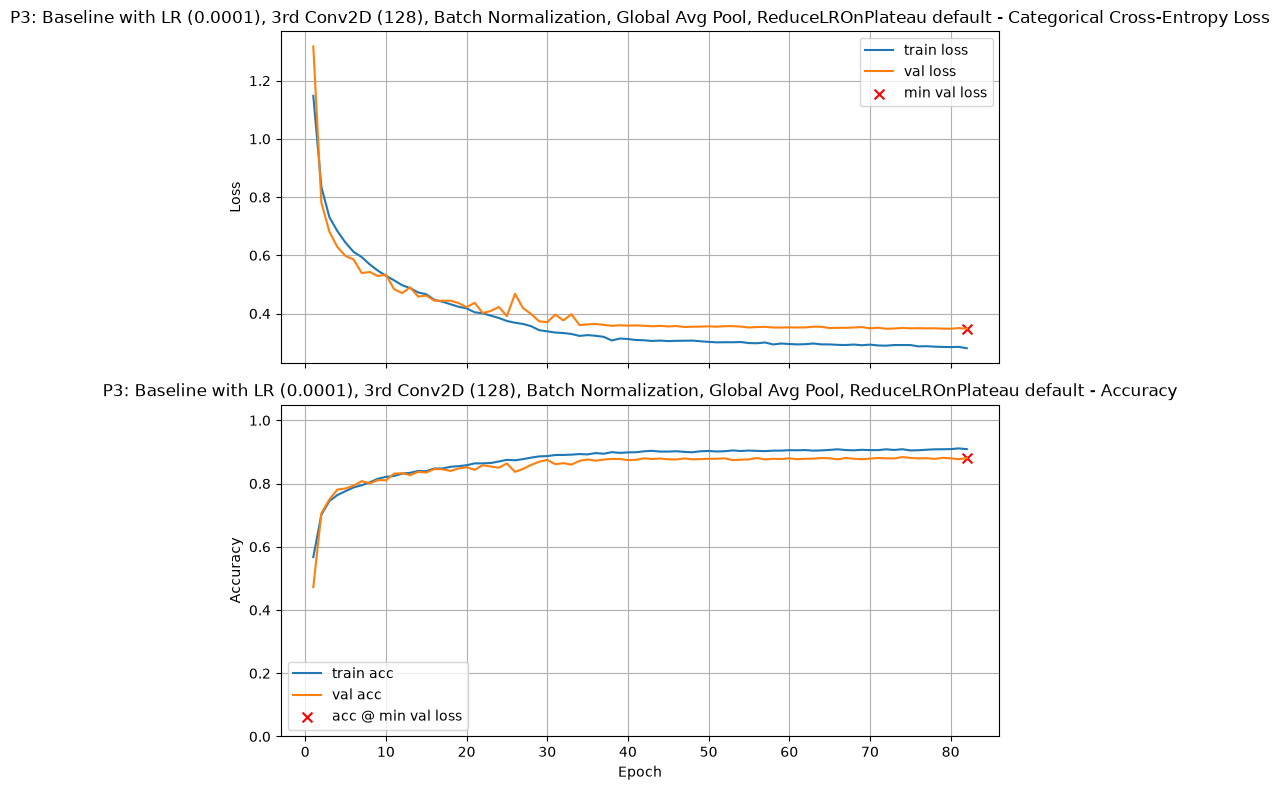

Final Training Loss:            0.2808
Final Training Accuracy:        0.9088
Final Validation Loss:          0.3478
Final Validation Accuracy:      0.8805
Minimum Validation Loss:        0.3478 (Epoch 82)
Validation Accuracy @ Min Loss: 0.8805

Test Loss: 0.3577
Test Accuracy: 0.8820

Validation-Test Gap (accuracy): 0.002185

Execution Time: 00:51:54


In [45]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=3,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=1,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-5,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

he = initializers.HeNormal()                                # best initializer for relu

lr = 1e-4

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
 
    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, callbacks=[reduce_lr], lr_schedule=lr, title=f"P3: Baseline with LR ({lr}), 3rd Conv2D (128), Batch Normalization, Global Avg Pool, ReduceLROnPlateau default")


P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau patience (5)



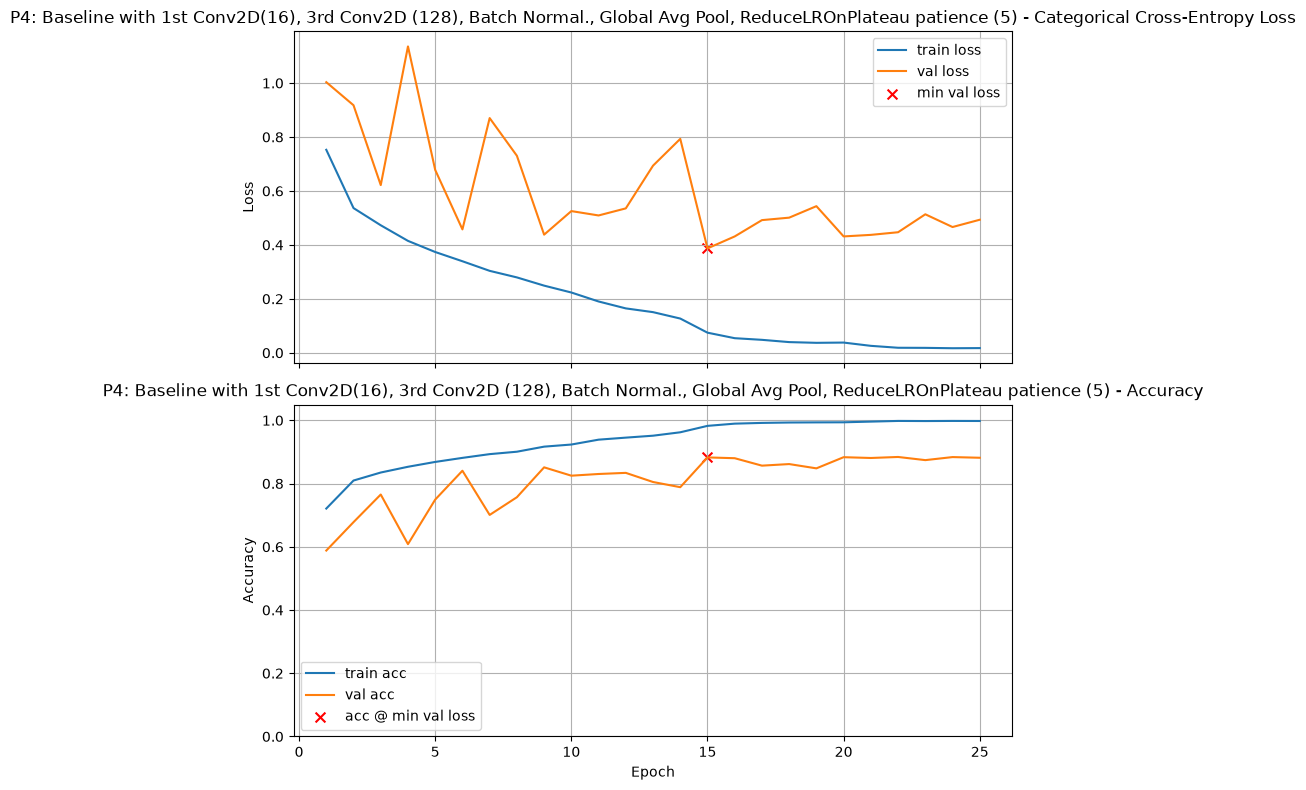

Final Training Loss:            0.0174
Final Training Accuracy:        0.9979
Final Validation Loss:          0.4933
Final Validation Accuracy:      0.8816
Minimum Validation Loss:        0.3871 (Epoch 15)
Validation Accuracy @ Min Loss: 0.8827

Test Loss: 0.3689
Test Accuracy: 0.8843

Validation-Test Gap (accuracy): 0.001666

Execution Time: 00:06:28


In [46]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=5,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=1,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-5,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

he = initializers.HeNormal()                                # best initializer for relu

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    
    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, callbacks=[reduce_lr], title=f"P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau patience (5)")


P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.3) patience (5)



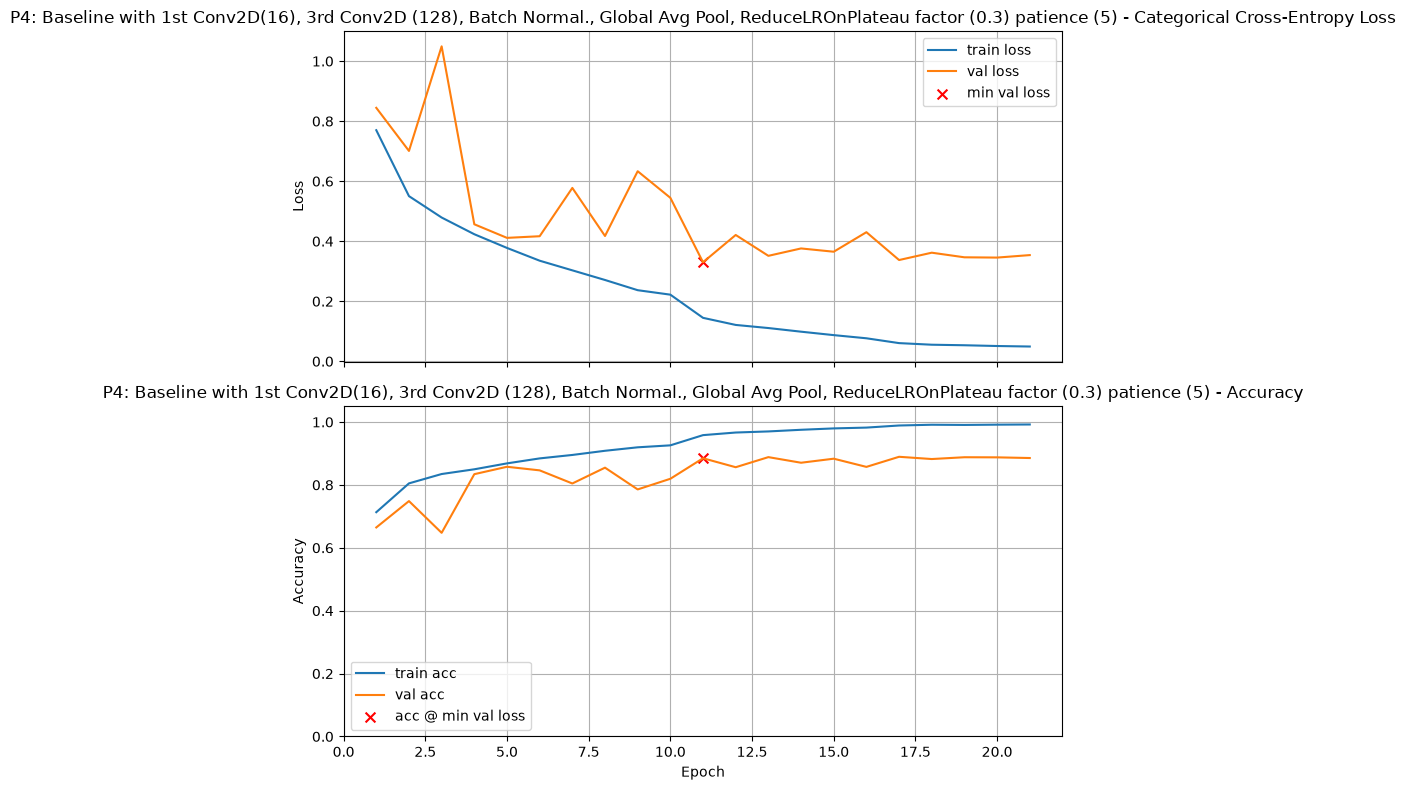

Final Training Loss:            0.0493
Final Training Accuracy:        0.9922
Final Validation Loss:          0.3539
Final Validation Accuracy:      0.8855
Minimum Validation Loss:        0.3300 (Epoch 11)
Validation Accuracy @ Min Loss: 0.8848

Test Loss: 0.3193
Test Accuracy: 0.8897

Validation-Test Gap (accuracy): 0.004859

Execution Time: 00:05:19


In [47]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.3,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=5,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=1,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-5,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

he = initializers.HeNormal()                                # best initializer for relu

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, callbacks=[reduce_lr], title=f"P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.3) patience (5)")


P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.2) patience (5)



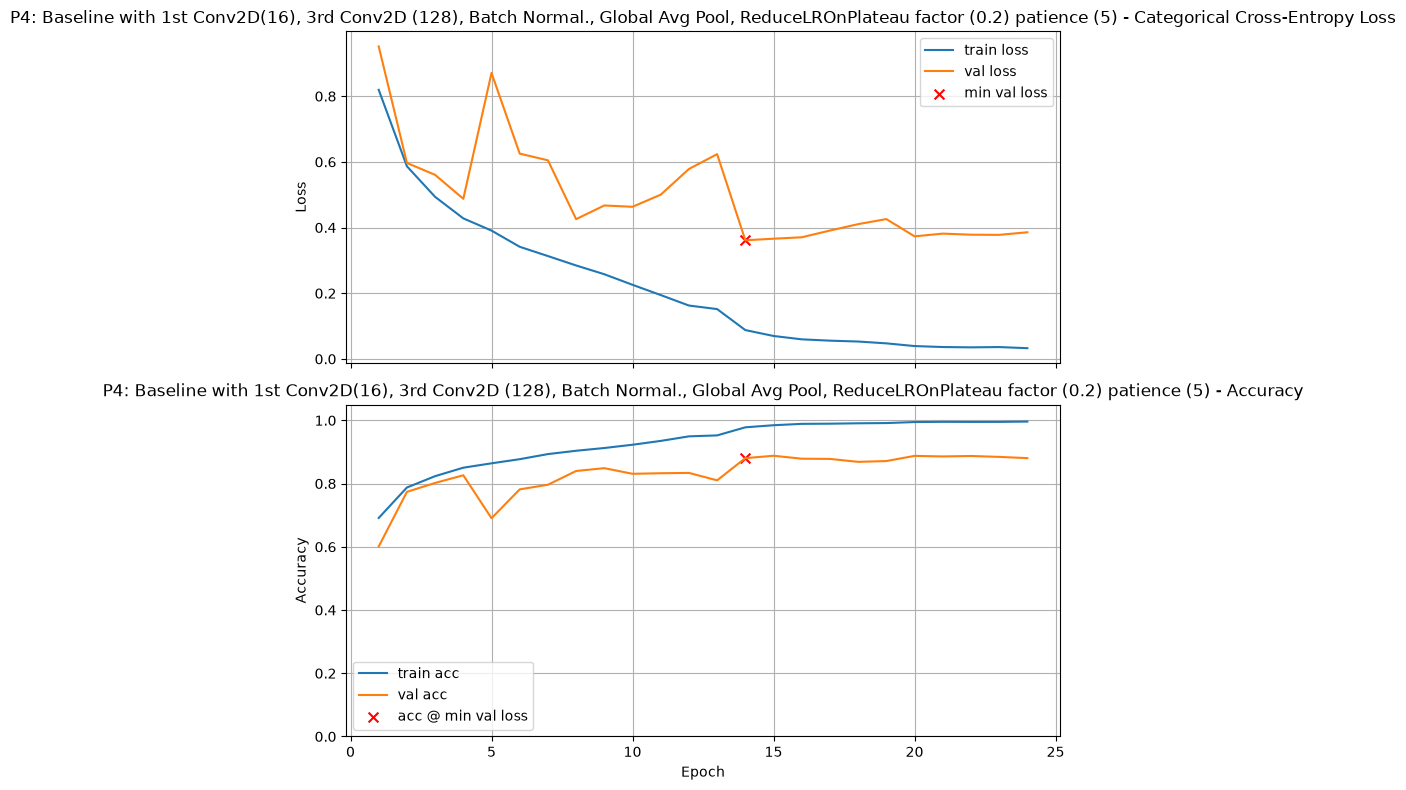

Final Training Loss:            0.0327
Final Training Accuracy:        0.9962
Final Validation Loss:          0.3857
Final Validation Accuracy:      0.8805
Minimum Validation Loss:        0.3613 (Epoch 14)
Validation Accuracy @ Min Loss: 0.8805

Test Loss: 0.3476
Test Accuracy: 0.8803

Validation-Test Gap (accuracy): 0.000194

Execution Time: 00:06:03


In [48]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.2,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=5,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=1,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-5,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

he = initializers.HeNormal()                                # best initializer for relu

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, callbacks=[reduce_lr], title=f"P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.2) patience (5)")


P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.2) patience (3)



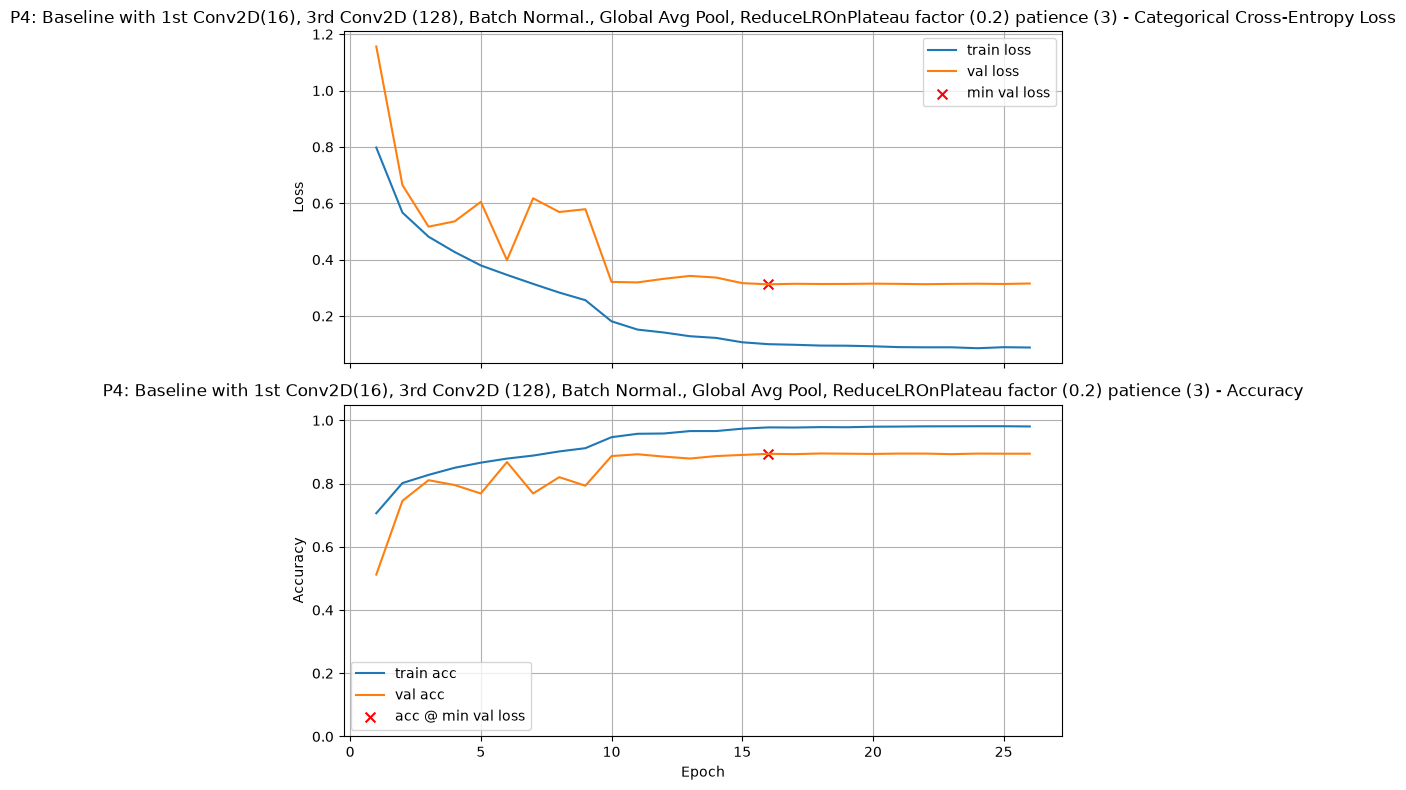

Final Training Loss:            0.0883
Final Training Accuracy:        0.9806
Final Validation Loss:          0.3154
Final Validation Accuracy:      0.8944
Minimum Validation Loss:        0.3125 (Epoch 16)
Validation Accuracy @ Min Loss: 0.8941

Test Loss: 0.3256
Test Accuracy: 0.8903

Validation-Test Gap (accuracy): 0.003747

Execution Time: 00:06:32


In [49]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.2,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=3,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=1,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-5,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

he = initializers.HeNormal()                                # best initializer for relu

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, callbacks=[reduce_lr], title=f"P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.2) patience (3)")


P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.2) patience (8)



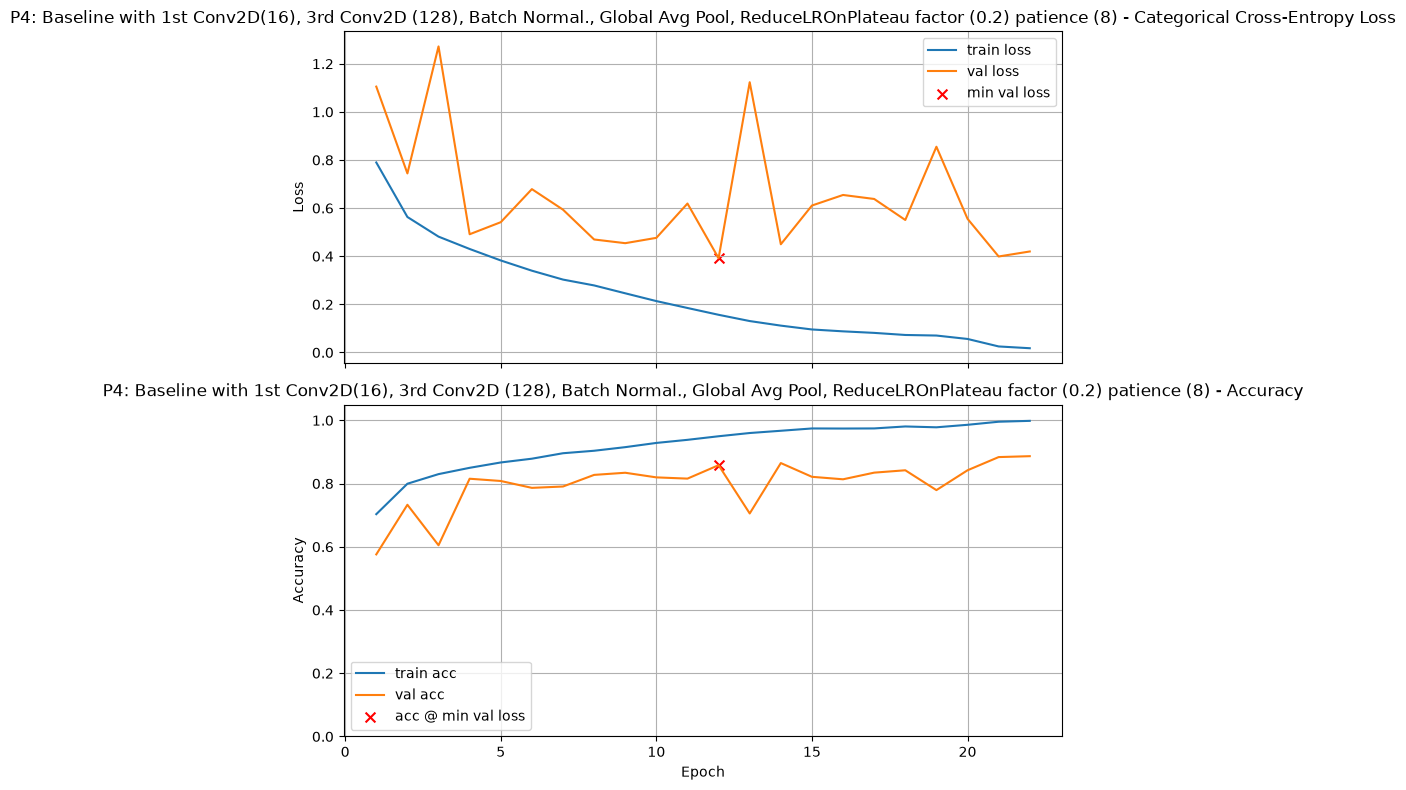

Final Training Loss:            0.0177
Final Training Accuracy:        0.9983
Final Validation Loss:          0.4198
Final Validation Accuracy:      0.8866
Minimum Validation Loss:        0.3919 (Epoch 12)
Validation Accuracy @ Min Loss: 0.8581

Test Loss: 0.3942
Test Accuracy: 0.8613

Validation-Test Gap (accuracy): 0.003273

Execution Time: 00:05:41


In [50]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.2,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=8,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=1,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-5,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

he = initializers.HeNormal()                                # best initializer for relu

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, callbacks=[reduce_lr], title=f"P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.2) patience (8)")


P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.2) patience (5) min_delta (1e-3)



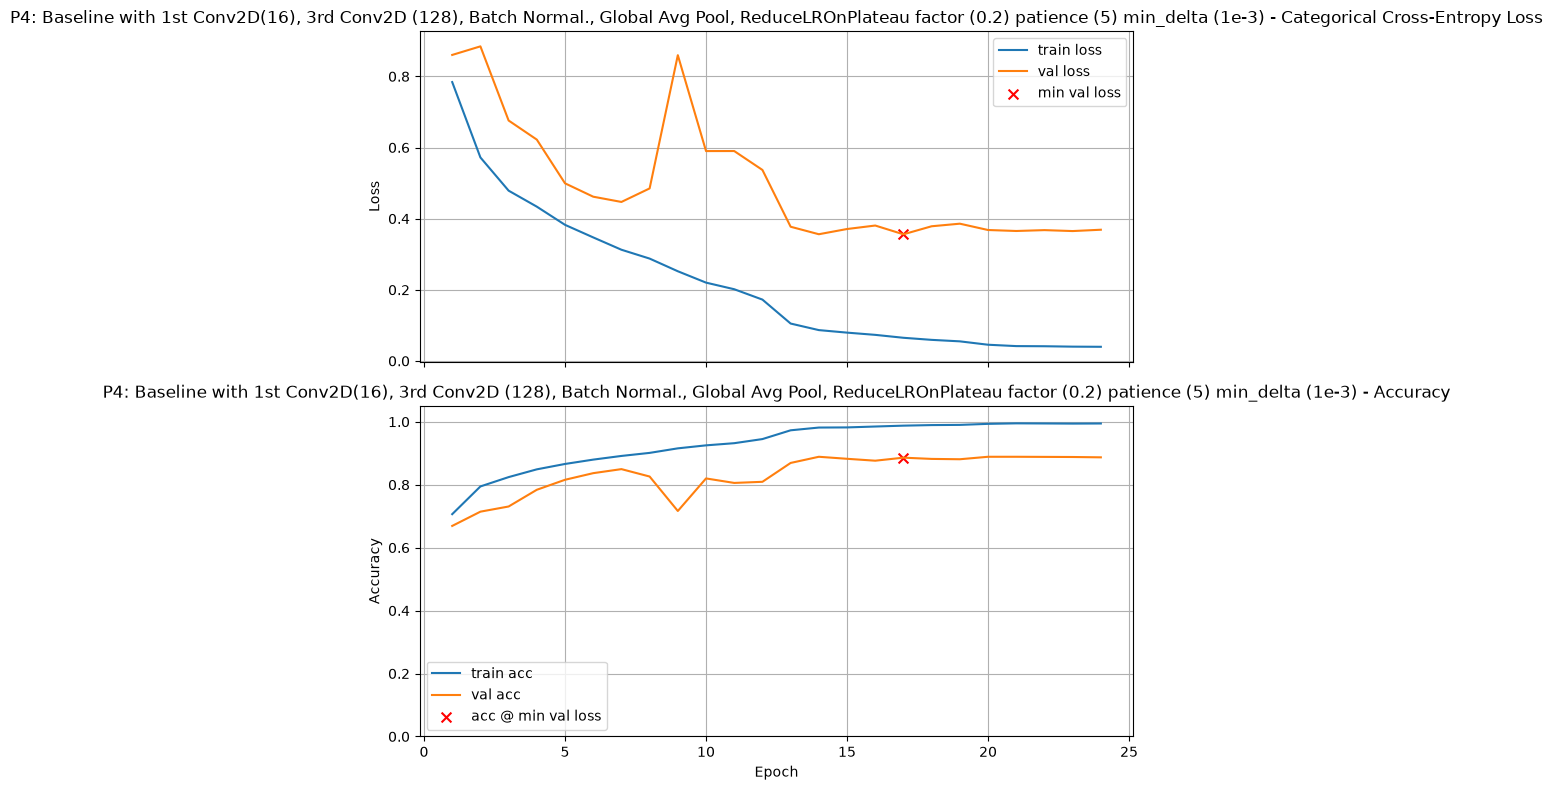

Final Training Loss:            0.0398
Final Training Accuracy:        0.9945
Final Validation Loss:          0.3689
Final Validation Accuracy:      0.8869
Minimum Validation Loss:        0.3560 (Epoch 17)
Validation Accuracy @ Min Loss: 0.8859

Test Loss: 0.3507
Test Accuracy: 0.8890

Validation-Test Gap (accuracy): 0.000270

Execution Time: 00:06:03


In [51]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.2,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=5,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-3,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=1,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-5,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

he = initializers.HeNormal()                                # best initializer for relu

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, callbacks=[reduce_lr], title=f"P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.2) patience (5) min_delta (1e-3)")


P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau patience (8)



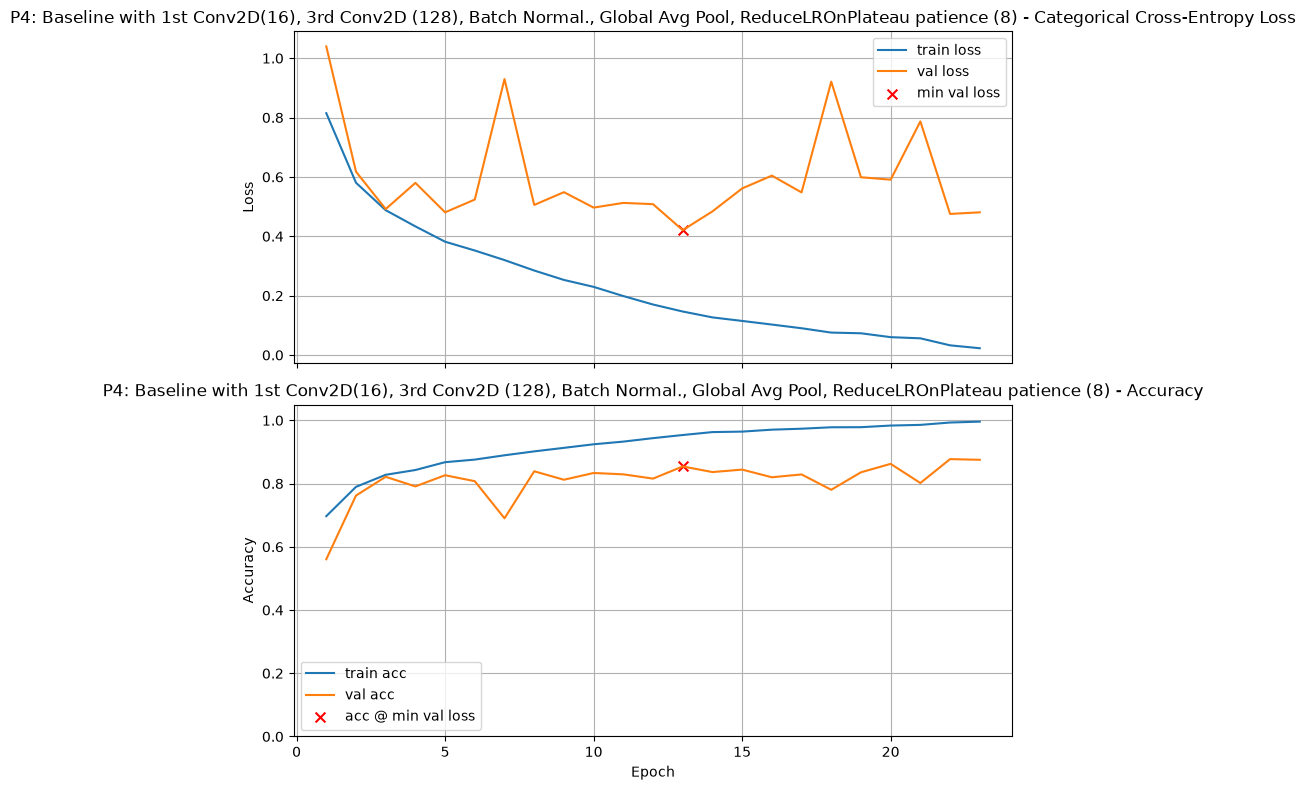

Final Training Loss:            0.0229
Final Training Accuracy:        0.9958
Final Validation Loss:          0.4807
Final Validation Accuracy:      0.8752
Minimum Validation Loss:        0.4208 (Epoch 13)
Validation Accuracy @ Min Loss: 0.8541

Test Loss: 0.4290
Test Accuracy: 0.8553

Validation-Test Gap (accuracy): 0.001196

Execution Time: 00:05:55


In [52]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=8,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=1,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-5,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

he = initializers.HeNormal()                                # best initializer for relu

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, callbacks=[reduce_lr], title=f"P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau patience (8)")


P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.7) patience (5) min_delta (1e-3)



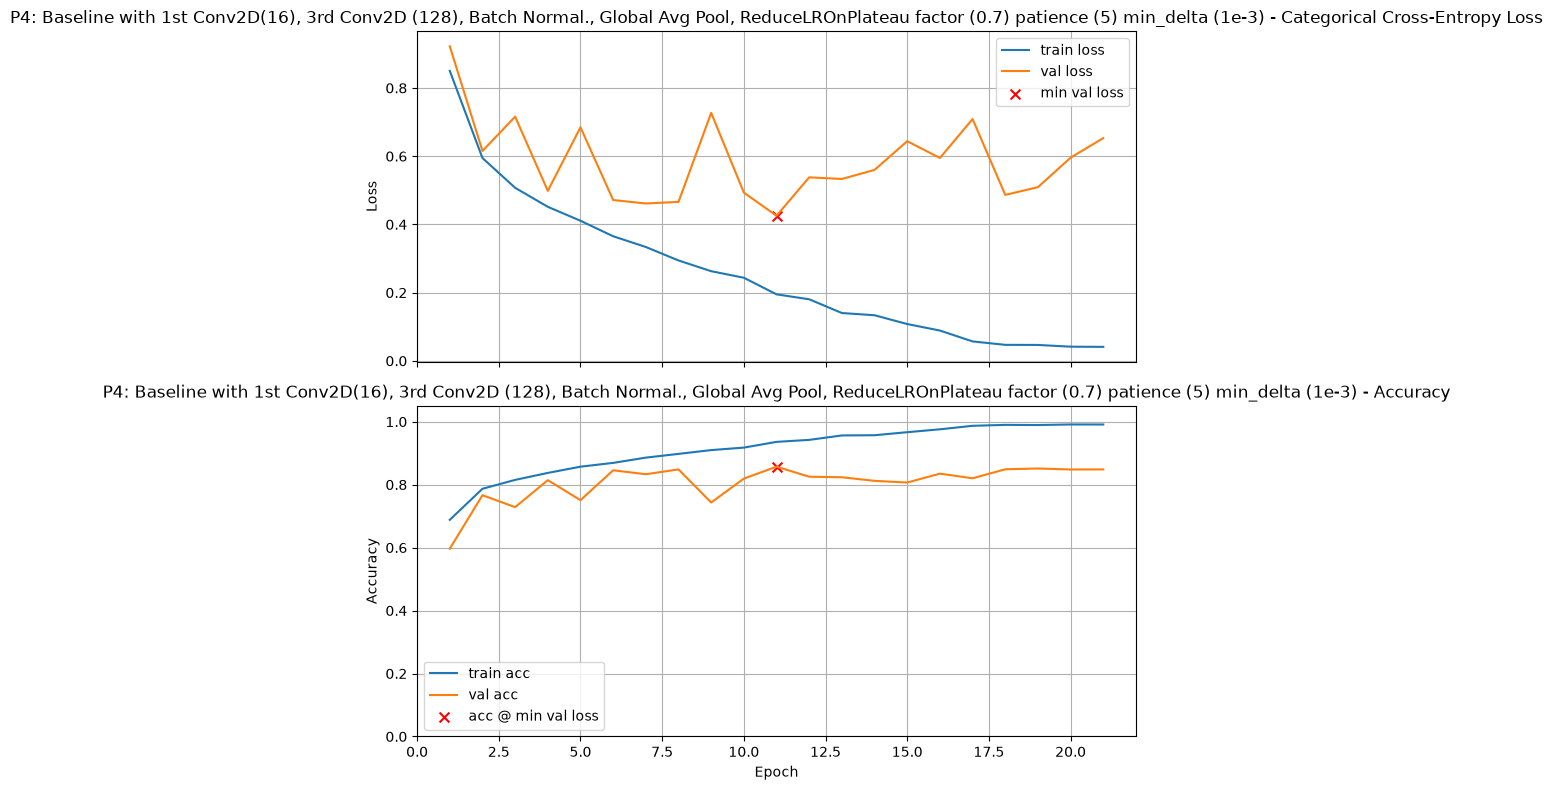

Final Training Loss:            0.0410
Final Training Accuracy:        0.9910
Final Validation Loss:          0.6531
Final Validation Accuracy:      0.8484
Minimum Validation Loss:        0.4255 (Epoch 11)
Validation Accuracy @ Min Loss: 0.8570

Test Loss: 0.4440
Test Accuracy: 0.8510

Validation-Test Gap (accuracy): 0.005990

Execution Time: 00:05:19


In [53]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.7,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=5,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-3,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=1,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-5,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

he = initializers.HeNormal()                                # best initializer for relu

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, callbacks=[reduce_lr], title=f"P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.7) patience (5) min_delta (1e-3)")


P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.7) patience (3) min_delta (1e-3)



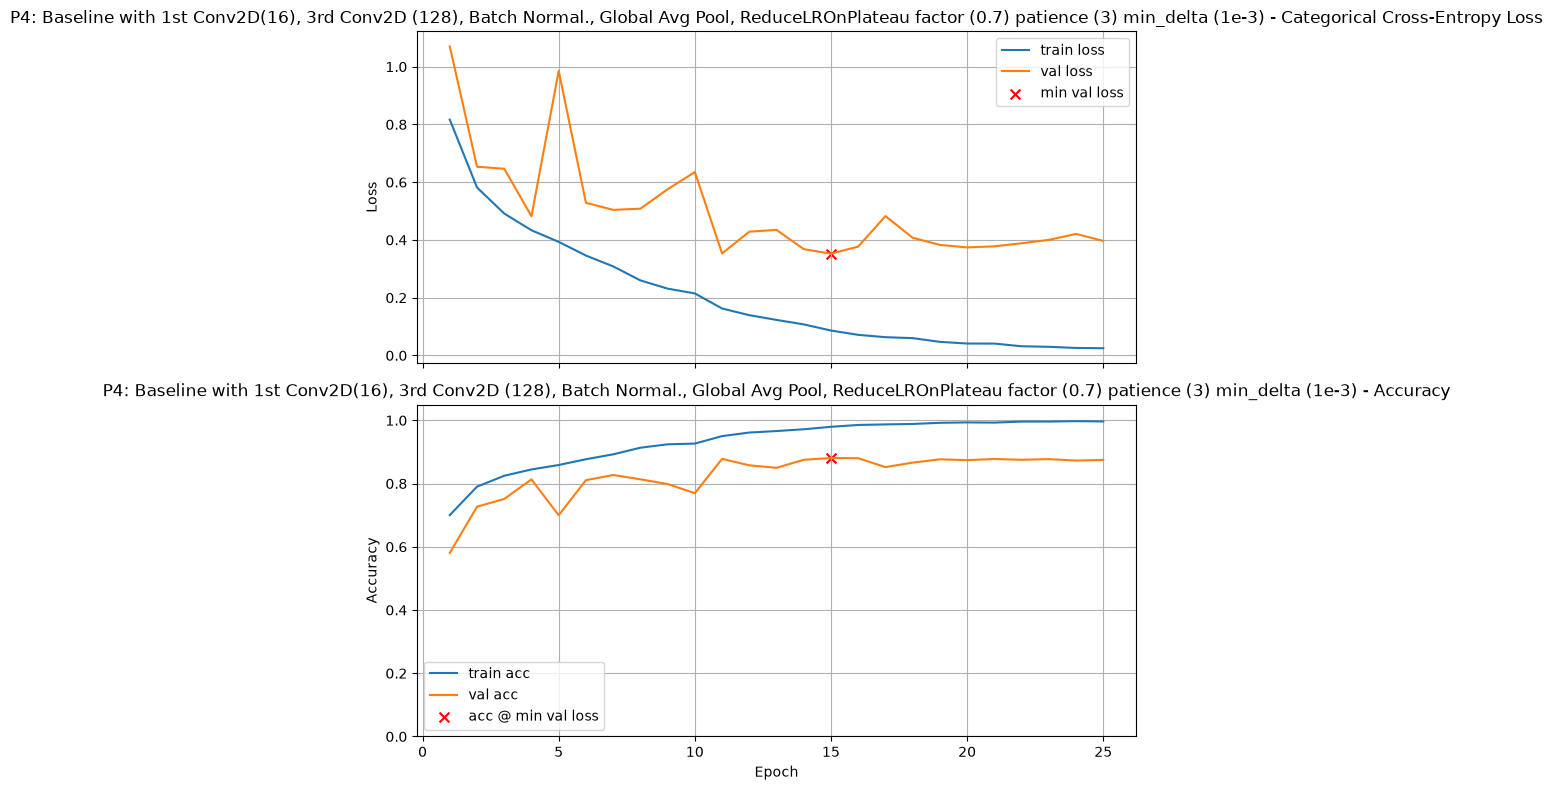

Final Training Loss:            0.0250
Final Training Accuracy:        0.9964
Final Validation Loss:          0.3967
Final Validation Accuracy:      0.8748
Minimum Validation Loss:        0.3523 (Epoch 15)
Validation Accuracy @ Min Loss: 0.8809

Test Loss: 0.3573
Test Accuracy: 0.8803

Validation-Test Gap (accuracy): 0.000551

Execution Time: 00:06:20


In [56]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.7,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=3,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-3,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=1,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-5,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

he = initializers.HeNormal()                                # best initializer for relu

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, callbacks=[reduce_lr], title=f"P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.7) patience (3) min_delta (1e-3)")


P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.7) patience (5)



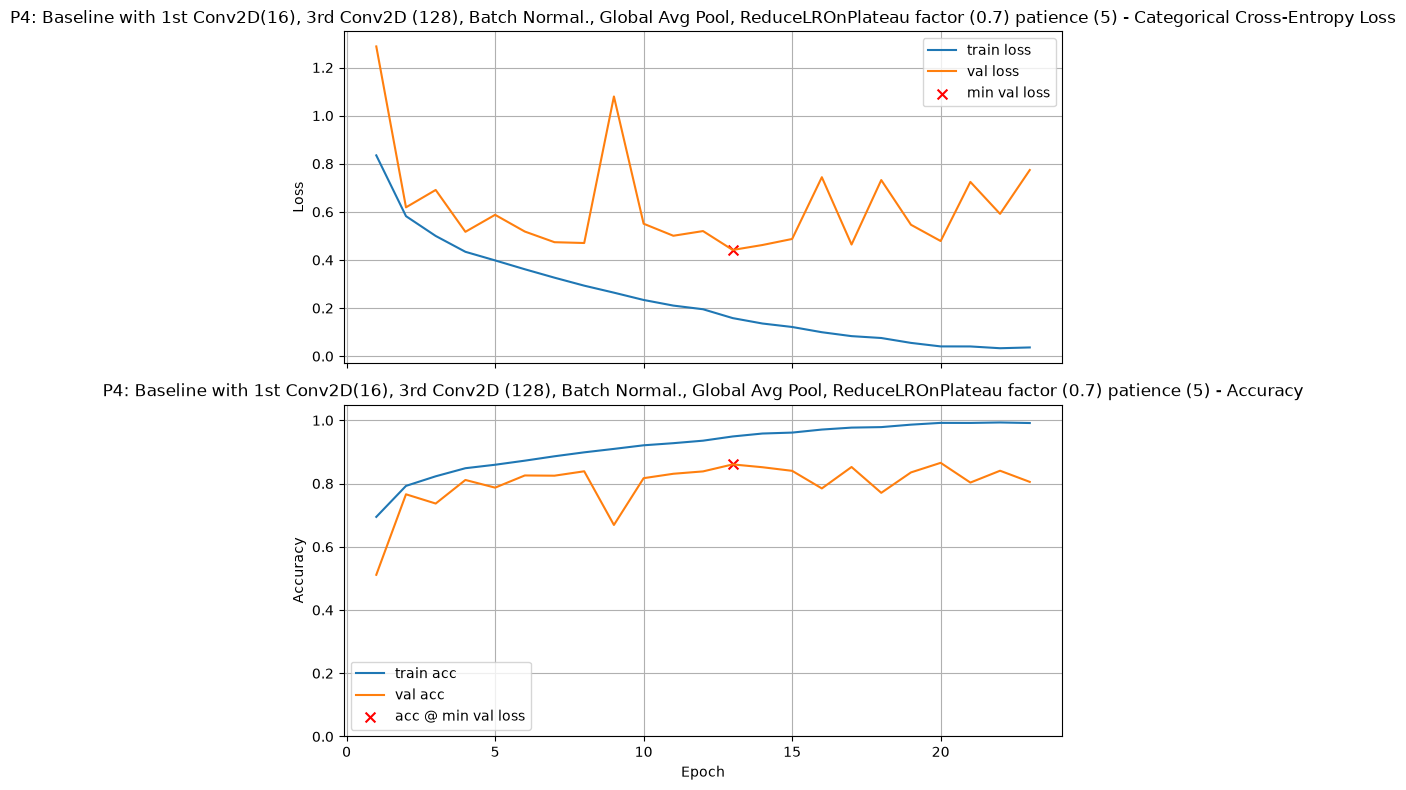

Final Training Loss:            0.0365
Final Training Accuracy:        0.9915
Final Validation Loss:          0.7740
Final Validation Accuracy:      0.8053
Minimum Validation Loss:        0.4417 (Epoch 13)
Validation Accuracy @ Min Loss: 0.8606

Test Loss: 0.4259
Test Accuracy: 0.8620

Validation-Test Gap (accuracy): 0.001444

Execution Time: 00:05:48


In [54]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.7,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=5,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=1,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-5,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

he = initializers.HeNormal()                                # best initializer for relu

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, callbacks=[reduce_lr], title=f"P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.7) patience (5)")


P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.7) patience (8)



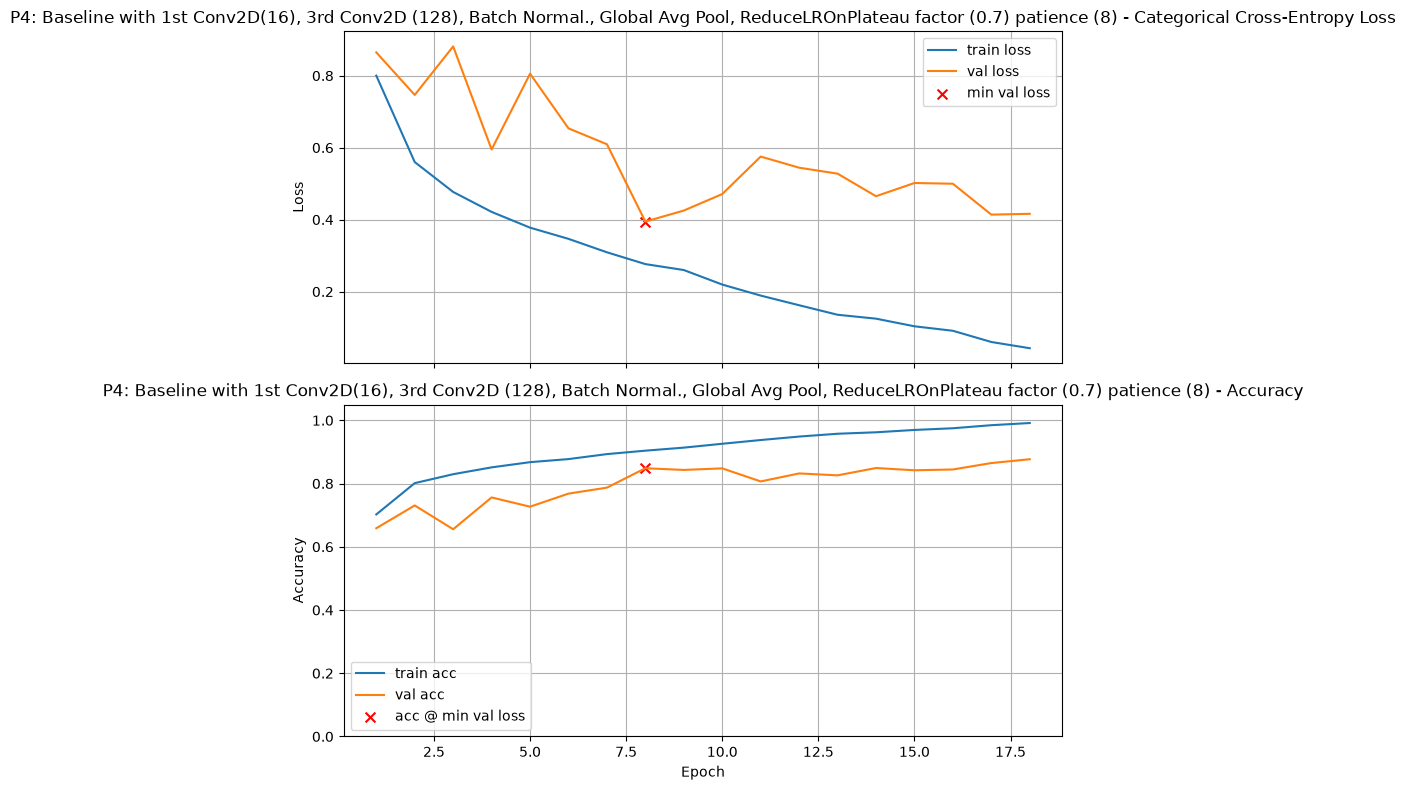

Final Training Loss:            0.0427
Final Training Accuracy:        0.9915
Final Validation Loss:          0.4162
Final Validation Accuracy:      0.8770
Minimum Validation Loss:        0.3946 (Epoch 8)
Validation Accuracy @ Min Loss: 0.8484

Test Loss: 0.3994
Test Accuracy: 0.8597

Validation-Test Gap (accuracy): 0.011236

Execution Time: 00:04:34


In [57]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.7,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=8,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=1,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-5,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

he = initializers.HeNormal()                                # best initializer for relu

model = models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    GlobalAveragePooling2D(),
    Dense(num_classes, activation="softmax")
])

train_and_test(model, callbacks=[reduce_lr], title=f"P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.7) patience (8)")

In [58]:
print_results()

P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.2) patience (3)	0.8941	16
P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.2) patience (5) min_delta (1e-3)	0.8859	17
P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.3) patience (5)	0.8848	11
P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau patience (5)	0.8827	15
P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.7) patience (3) min_delta (1e-3)	0.8809	15
P3: Baseline with LR (0.0001), 3rd Conv2D (128), Batch Normalization, Global Avg Pool, ReduceLROnPlateau default	0.8805	82
P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.2) patience (5)	0.8805	14
P3: Baseline with 3rd Conv2D

### Graded Questions

In [59]:
# Set a4a to the factor parameter which gave the best validation accuracy at the point of minimum validation loss

a4a = 0.2             # Replace with your best factor value, or set to -1 if reduce on plateau did not help at all

In [60]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a4a = {a4a:.2f}')

a4a = 0.20


In [61]:
# Set a4b to the validation accuracy found by the choice specified in Question a4a (your best model for this problem)

a4b = results['P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.2) patience (3)'][0]             # Replace 0.0 with your answer

In [62]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a4b = {a4b:.4f}')

a4b = 0.8941


## Problem Five: A Very Deep CNN (VGG-16 Style)

 We will now experiment with the VGG-16 design introduced in the Coding Notebook and Video and see how it does on this dataset. For a beautiful description of the model and its significance, see [Explanation of VGG-16](https://viso.ai/deep-learning/vgg-very-deep-convolutional-networks/) :
        

![Screenshot 2025-09-19 at 6.50.24 AM.png](attachment:62fa0824-bb06-4663-a6a5-da8cca8f4ab3.png)


In this exercise you’ll **only vary the learning rate**. Don’t change any other hyperparameters. Your goal is to observe how LR affects convergence speed, stability, and final validation performance compared to your smaller baselines. This sets up next week’s **transfer learning** with pretrained models.

#### Starting point

* Optimizer: **Adam**
* **Recommended LR to start:** `1e-3`(Adam default)

#### What LR values to try (coarse → fine)

Try a short sweep like:

```
[1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5]
```

Then, as time allows,  zoom in around the best.

#### How to judge “best”

* Primary: **best validation accuracy at epoch of lowest validation loss**
* Secondary: **time-to-best** (fewer epochs to reach a strong val metric) and **curve shape** (smooth vs. noisy/oscillatory).

#### What symptoms mean

* **LR too high:** training loss spikes or oscillates; val metrics erratic, occasional NaNs/divergence.
* **LR too low:** very slow improvement; long flat regions; never reaches your smaller models’ performance.


**Tip:** Keep LR **constant** during each run (don’t schedule) so you isolate its effect.



In [69]:
# Saving progress so I can restart kernel with GPU enabled

import pandas as pd

# Convert results dictionary into a sorted DataFrame
df_results = pd.DataFrame([
    {"Model": title, "Accuracy": acc, "Epochs": ep}
    for title, (acc, ep) in results.items()
]).sort_values(by="Accuracy", ascending=False)

# Save to disk
df_results.to_csv("results.csv", index=False)
df_results.head()

,Model,Accuracy,Epochs
17,"P4: Baseline with 1st Conv2D(16), 3rd Conv2D (...",0.894080,16
19,"P4: Baseline with 1st Conv2D(16), 3rd Conv2D (...",0.885877,17
15,"P4: Baseline with 1st Conv2D(16), 3rd Conv2D (...",0.884807,11
14,"P4: Baseline with 1st Conv2D(16), 3rd Conv2D (...",0.882668,15
23,"P4: Baseline with 1st Conv2D(16), 3rd Conv2D (...",0.880884,15


In [20]:
import pandas as pd
results_df = pd.read_csv('results.csv')


VGG-style Large



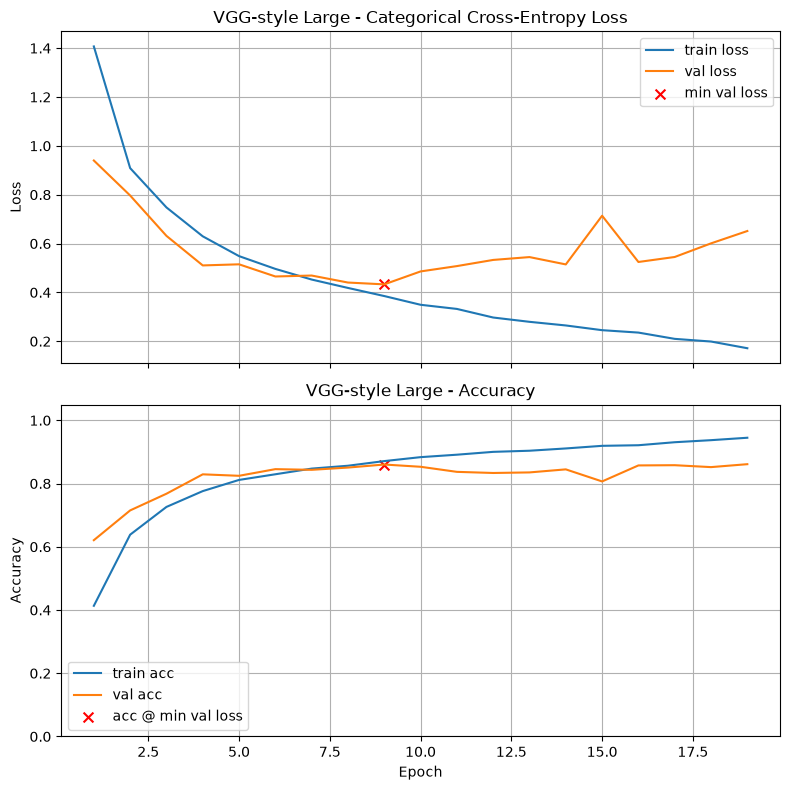

Final Training Loss:            0.1716
Final Training Accuracy:        0.9449
Final Validation Loss:          0.6513
Final Validation Accuracy:      0.8613
Minimum Validation Loss:        0.4330 (Epoch 9)
Validation Accuracy @ Min Loss: 0.8602

Test Loss: 0.4320
Test Accuracy: 0.8533

Validation-Test Gap (accuracy): 0.006866

Execution Time: 02:15:36


In [13]:
he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)   # set to None to disable or tweak the value

model_vgg_16 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 4 (NO MaxPool here -> leaves 3×3×512)
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

    # Global pooling meaningfully summarizes the 3×3 map
    layers.GlobalAveragePooling2D(),   # swap to GlobalMaxPooling2D() to compare

    # Compact head
    layers.Dense(256, activation='relu', kernel_initializer=he,
                 kernel_regularizer=l2reg),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Uncomment the next line to run

train_and_test(model_vgg_16,lr_schedule=1e-3,title="VGG-style Large")



VGG-style Large (LR: 0.01)



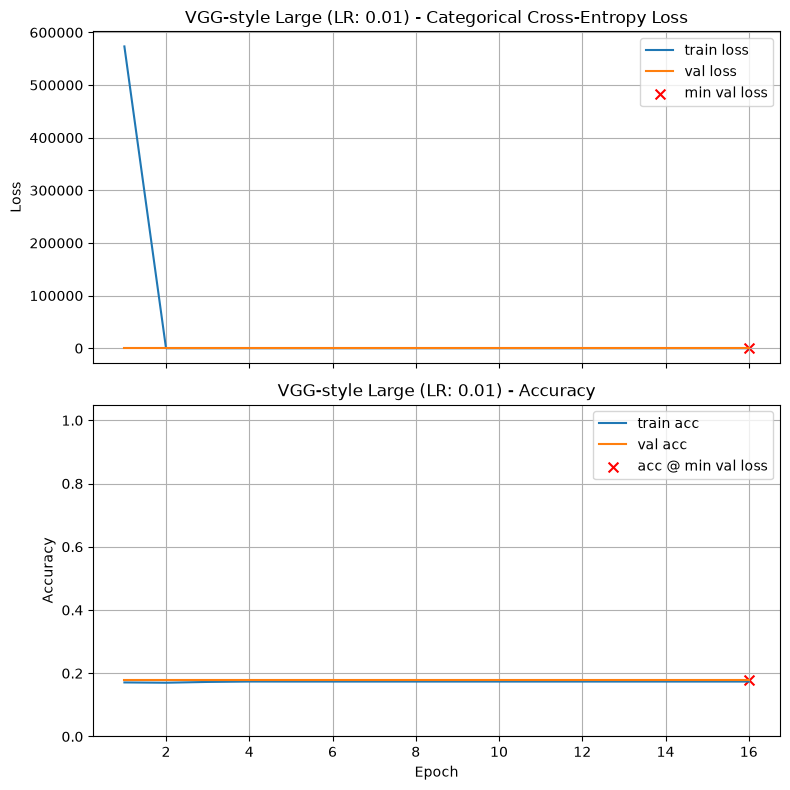

Final Training Loss:            1.8104
Final Training Accuracy:        0.1737
Final Validation Loss:          1.8105
Final Validation Accuracy:      0.1790
Minimum Validation Loss:        1.8105 (Epoch 16)
Validation Accuracy @ Min Loss: 0.1790

Test Loss: 1.8103
Test Accuracy: 0.1750

Validation-Test Gap (accuracy): 0.004030

Execution Time: 01:51:32


In [14]:
# [1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5]

lr = 1e-2

he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)   # set to None to disable or tweak the value

model_vgg_16 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 4 (NO MaxPool here -> leaves 3×3×512)
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

    # Global pooling meaningfully summarizes the 3×3 map
    layers.GlobalAveragePooling2D(),   # swap to GlobalMaxPooling2D() to compare

    # Compact head
    layers.Dense(256, activation='relu', kernel_initializer=he,
                 kernel_regularizer=l2reg),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Uncomment the next line to run

train_and_test(model_vgg_16,lr_schedule=lr,title=f"VGG-style Large (LR: {lr})")



VGG-style Large (LR: 0.003)



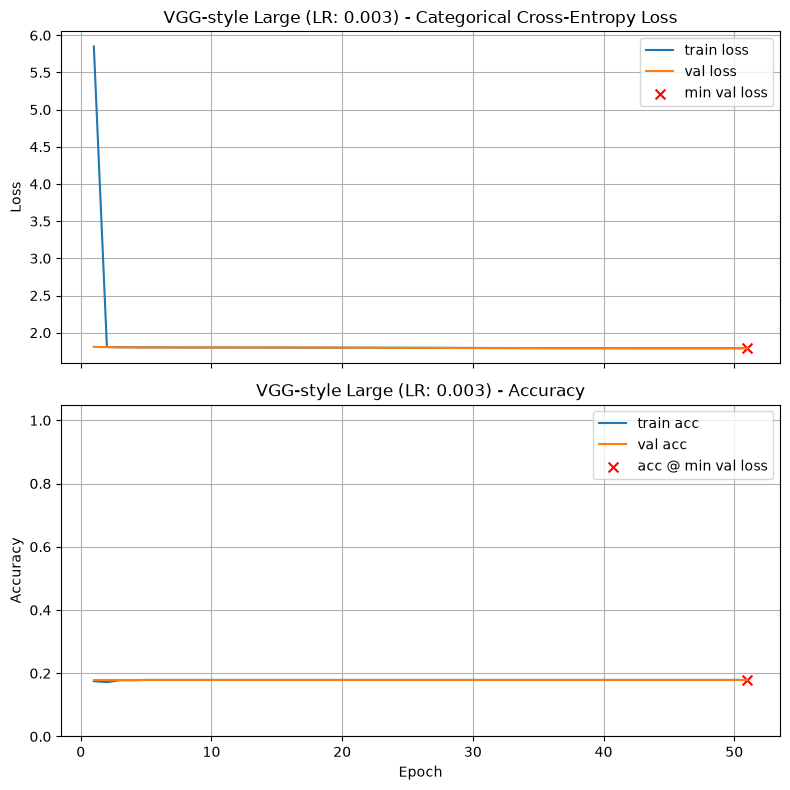

Final Training Loss:            1.7912
Final Training Accuracy:        0.1790
Final Validation Loss:          1.7909
Final Validation Accuracy:      0.1790
Minimum Validation Loss:        1.7909 (Epoch 51)
Validation Accuracy @ Min Loss: 0.1790

Test Loss: 1.7903
Test Accuracy: 0.1750

Validation-Test Gap (accuracy): 0.004030

Execution Time: 05:52:33


In [15]:
# [1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5]

lr = 3e-3

he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)   # set to None to disable or tweak the value

model_vgg_16 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 4 (NO MaxPool here -> leaves 3×3×512)
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

    # Global pooling meaningfully summarizes the 3×3 map
    layers.GlobalAveragePooling2D(),   # swap to GlobalMaxPooling2D() to compare

    # Compact head
    layers.Dense(256, activation='relu', kernel_initializer=he,
                 kernel_regularizer=l2reg),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Uncomment the next line to run

train_and_test(model_vgg_16,lr_schedule=lr,title=f"VGG-style Large (LR: {lr})")



VGG-style Large (LR: 0.0003)



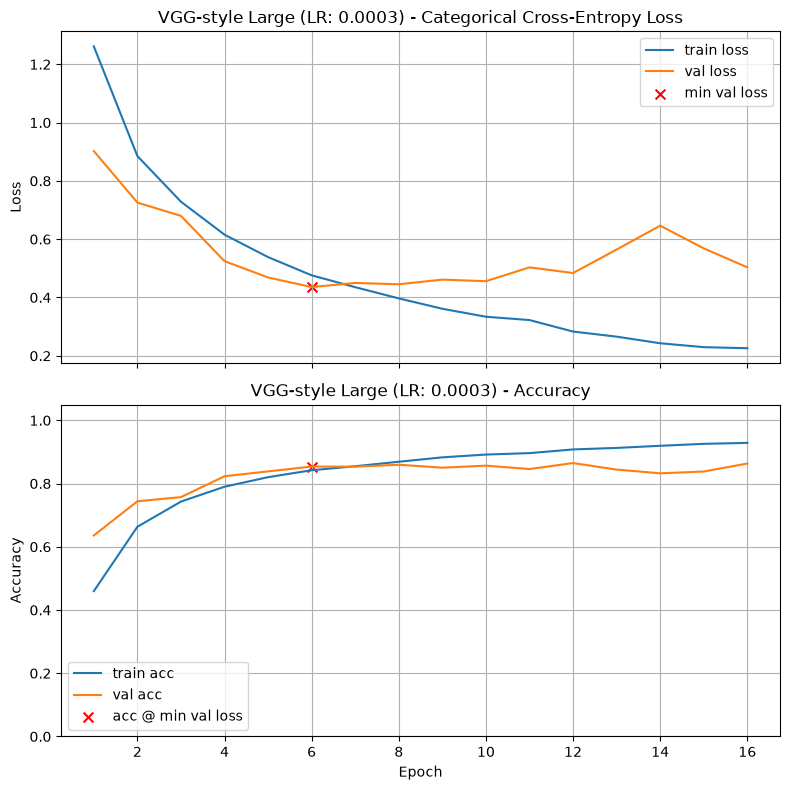

Final Training Loss:            0.2260
Final Training Accuracy:        0.9287
Final Validation Loss:          0.5035
Final Validation Accuracy:      0.8634
Minimum Validation Loss:        0.4358 (Epoch 6)
Validation Accuracy @ Min Loss: 0.8538

Test Loss: 0.4390
Test Accuracy: 0.8503

Validation-Test Gap (accuracy): 0.003447

Execution Time: 01:46:23


In [16]:
# [1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5]

lr = 3e-4

he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)   # set to None to disable or tweak the value

model_vgg_16 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 4 (NO MaxPool here -> leaves 3×3×512)
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

    # Global pooling meaningfully summarizes the 3×3 map
    layers.GlobalAveragePooling2D(),   # swap to GlobalMaxPooling2D() to compare

    # Compact head
    layers.Dense(256, activation='relu', kernel_initializer=he,
                 kernel_regularizer=l2reg),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Uncomment the next line to run

train_and_test(model_vgg_16,lr_schedule=lr,title=f"VGG-style Large (LR: {lr})")



VGG-style Large (LR: 0.0001)



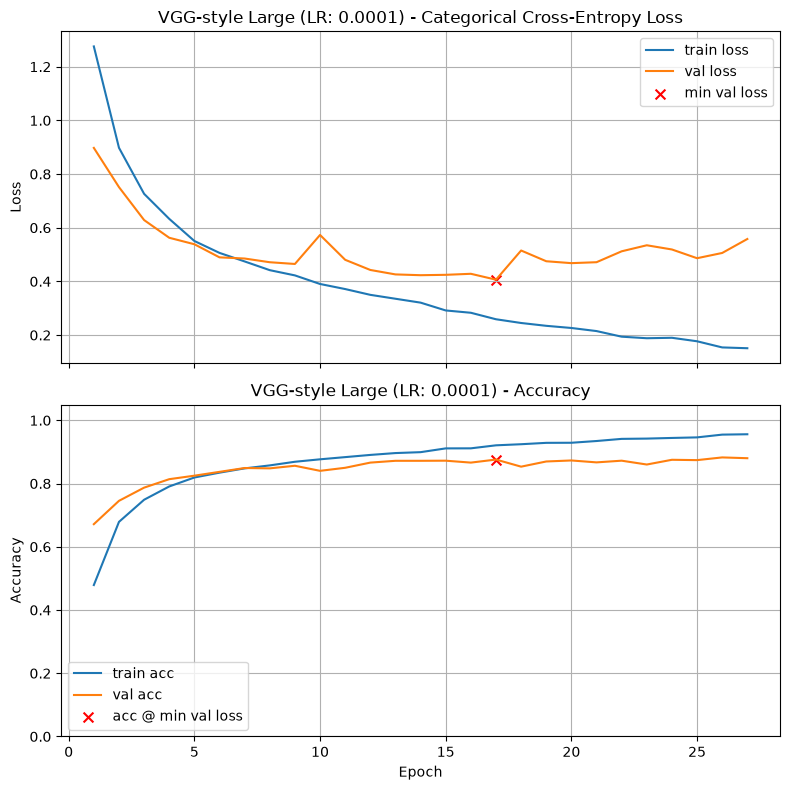

Final Training Loss:            0.1510
Final Training Accuracy:        0.9559
Final Validation Loss:          0.5580
Final Validation Accuracy:      0.8802
Minimum Validation Loss:        0.4065 (Epoch 17)
Validation Accuracy @ Min Loss: 0.8759

Test Loss: 0.4147
Test Accuracy: 0.8757

Validation-Test Gap (accuracy): 0.000225

Execution Time: 03:00:06


In [17]:
# [1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5]

lr = 1e-4

he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)   # set to None to disable or tweak the value

model_vgg_16 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 4 (NO MaxPool here -> leaves 3×3×512)
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

    # Global pooling meaningfully summarizes the 3×3 map
    layers.GlobalAveragePooling2D(),   # swap to GlobalMaxPooling2D() to compare

    # Compact head
    layers.Dense(256, activation='relu', kernel_initializer=he,
                 kernel_regularizer=l2reg),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Uncomment the next line to run

train_and_test(model_vgg_16,lr_schedule=lr,title=f"VGG-style Large (LR: {lr})")


In [22]:
results.update({
    row["Model"]: (float(row["Accuracy"]), int(row["Epochs"]))
    for _, row in results_df.iterrows()
})

### Graded Questions

In [24]:
# Set a5a to the learning rate which gave the best validation accuracy at the point of minimum validation loss

a5a = 1e-4             # Replace with your best learning rate

In [25]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a5a = {a5a:.8f}')

a5a = 0.00010000


In [26]:
# Set a5b to the validation accuracy found by the choice specified in Question a5a (your best model for this problem)

a5b = results['VGG-style Large (LR: 0.0001)'][0]              # Replace 0.0 with your answer

In [27]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a5b = {a5b:.4f}')

a5b = 0.8759


## All Results

This will print out the results from all experiments, with titles as keys. I use this all the time to keep track of experiments!

In [23]:
print_results()

P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.2) patience (3)	0.8941	16
P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.2) patience (5) min_delta (1e-3)	0.8859	17
P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.3) patience (5)	0.8848	11
P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau patience (5)	0.8827	15
P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.7) patience (3) min_delta (1e-3)	0.8809	15
P4: Baseline with 1st Conv2D(16), 3rd Conv2D (128), Batch Normal., Global Avg Pool, ReduceLROnPlateau factor (0.2) patience (5)	0.8805	14
P3: Baseline with LR (0.0001), 3rd Conv2D (128), Batch Normalization, Global Avg Pool, ReduceLROnPlateau default	0.8805	82
P3: Baseline with 3rd Conv2D